# β stabilisation and mode type: GFTM (FILTER=0.5) and TGLF against GS2 (M1_A1_NE, R3, R4)

γ vs β at fixed ky, one figure per code against GS2, for each case. Codes: GFTM widths 0.4 / 0.6 / 0.7 / 0.8
(`scan_beta_f05`, FILTER=0.5), TGLF default / V5 (`scan_beta_modes`) and TGLF V3 (older `scan_beta` scan). All scans
use GS2's own (ky, β) grid; TGLF V3's M1_A1_NE scan has two extra ky (0.2, 0.3) that are dropped. The single-ky
figures draw all three TGLF settings next to each code.

**Line styles.** GS2 black (dominant mode only). Code: dominant mode (`argmax` of `growth_rate` over `mode`, never
index 0) solid, the other mode dashed (`NMODES=2`).

**Markers = mode type** from `general_analysis.mode_classification` (cutoffs `T_BAL`, `T_TEAR`, see that module):
▲ MTM (tearing parity), ■ KBM (ballooning parity), ● mixed, × unclassified. Markers are drawn only where γ > 0.
- **GS2** uses all four indicators (tearing parameter T, ω sign, χe/χi, De/χe) from each run's final time.
- **GFTM / TGLF** linear runs have no per-mode flux weights, so they are classified on **T and ω only**, with the
  same cutoffs: KBM = ω>0 and T<`T_BAL`; MTM = ω<0 and T>`T_TEAR`; otherwise mixed. A code marker is therefore a
  looser test than a GS2 one, and "KBM" there means only "ballooning parity, ion direction".
- T for GFTM / TGLF is the `tearing_parameter` stored per mode in each leaf's `pyroscan.nc`. TGLF V3's older scan
  stores no `tearing_parameter`, so its points are × (unclassified), not guessed.
- Every scan is read with `PyroScan(pyroscan_json=..., load_base_pyro=True).load_gk_output(netcdf_file=...)`;
  no per-run outputs are loaded, except GS2's γ(t) in section (4), which a `pyroscan.nc` does not store.

**β axis.** Code scans store pyrokinetics β (= GS2's number × a per-case factor f); the x axis here is **GS2's β
number**, matched by index. f is printed below and checked constant. TGLF V3 stores GS2's number directly (f = 1),
but its `input.tglf` BETAE equals TGLF V5's at the same index (checked R4 and M1_A1_NE, lowest and highest β), so
the index match is the same physical β.

## Imports and settings

In [27]:
from pathlib import Path
import os
import numpy as np
import xarray as xr
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pyrokinetics import Pyro, PyroScan
from pyrokinetics.diagnostics.field_line import FieldLine
from general_analysis import mode_classification as mc

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "beta_stabilisation_f05"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
run_template = "Runs"

cases = ["M1_A1_NE", "R3", "R4"]
ky_targets = [0.1, 0.2, 0.3, 0.5]          # snapped to the nearest GS2 grid value, shown in the panel titles

# GS2 reference: data_root / code / run_template / project / case / scan_information
gs2_code, gs2_project, gs2_scan = "GS2", "scan_beta", "parameter_scan_GS2"
# Codes, one figure each: label -> (code, project, scan_information = leaf). Same three path parts for every case.
codes = {
    "GFTM w0.4": ("GFTM", "scan_beta_f05", "w0p4"),
    "GFTM w0.6": ("GFTM", "scan_beta_f05", "w0p6"),
    "GFTM w0.7": ("GFTM", "scan_beta_f05", "w0p7"),
    "GFTM w0.8": ("GFTM", "scan_beta_f05", "w0p8"),
    "TGLF default": ("TGLF", "scan_beta_modes", "default"),
    "TGLF V5": ("TGLF", "scan_beta_modes", "v5"),
    "TGLF V3": ("TGLF", "scan_beta", "parameter_scan_tglf_v3"),   # older scan: no tearing_parameter, beta stored as GS2's number
}
metadata_file, output_file = "pyroscan.json", "pyroscan.nc"   # in every scan directory
gamma_floor = 0.0                                        # markers only where gamma > this
n_spot, seed = 3, 0                                      # spot-check cells per (case, code family)

## Load data

Every leaf as a `PyroScan` from its `pyroscan.json` + `pyroscan.nc` (base pyro from `pyroscan_base.input`); the
plain datasets below are its `gk_output` with units stripped. GS2 and the codes must share the ky grid exactly; nothing is
interpolated.

In [28]:
def scan(code, project, case, leaf):
    d = data_root / code / run_template / project / case / leaf
    s = PyroScan(pyroscan_json=d / metadata_file, load_base_pyro=True)
    s.load_gk_output(netcdf_file=d / output_file)
    return s

gs2_pyroscan = {c: scan(gs2_code, gs2_project, c, gs2_scan) for c in cases}
model_pyroscan = {(c, lab): scan(code, project, c, leaf) for c in cases for lab, (code, project, leaf) in codes.items()}
gs2 = {c: s.gk_output.data.pint.dequantify() for c, s in gs2_pyroscan.items()}
model = {k: s.gk_output.data.pint.dequantify() for k, s in model_pyroscan.items()}

for (c, lab), ds in model.items():   # exact selection on GS2's ky (KeyError if one is missing); report what is dropped
    extra = np.setdiff1d(ds.ky.values, gs2[c].ky.values)
    if extra.size:
        print(c, lab, "ky not in GS2, dropped:", extra)
        model[(c, lab)] = ds.sel(ky=gs2[c].ky.values)

for c in cases:
    for lab in codes:
        ds = model[(c, lab)]
        assert np.array_equal(ds.ky.values, gs2[c].ky.values), (c, lab, "ky grid differs from GS2")
        ratio = ds.beta.values / gs2[c].beta.values
        assert np.allclose(ratio, ratio[0], rtol=1e-3), (c, lab, "beta is not GS2 beta x constant")
    print(c, "ky", gs2[c].ky.size, "beta", gs2[c].beta.size, "| pyro beta / GS2 beta f =",
          {lab: round(float(model[(c, lab)].beta.values[0] / gs2[c].beta.values[0]), 4) for lab in codes},
          "| modes", {lab: int(model[(c, lab)].mode.size) for lab in codes})

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:944: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0046'. 
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:944: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0049'. 
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:944: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0050'. 
  warnings.warn(
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-package

M1_A1_NE TGLF V3 ky not in GS2, dropped: [0.2 0.3]
M1_A1_NE ky 40 beta 19 | pyro beta / GS2 beta f = {'GFTM w0.4': 1.0, 'GFTM w0.6': 1.0, 'GFTM w0.7': 1.0, 'GFTM w0.8': 1.0, 'TGLF default': 1.0, 'TGLF V5': 1.0, 'TGLF V3': 1.0} | modes {'GFTM w0.4': 2, 'GFTM w0.6': 2, 'GFTM w0.7': 2, 'GFTM w0.8': 2, 'TGLF default': 2, 'TGLF V5': 2, 'TGLF V3': 2}
R3 ky 42 beta 19 | pyro beta / GS2 beta f = {'GFTM w0.4': 0.9546, 'GFTM w0.6': 0.9546, 'GFTM w0.7': 0.9546, 'GFTM w0.8': 0.9546, 'TGLF default': 0.9546, 'TGLF V5': 0.9546, 'TGLF V3': 1.0} | modes {'GFTM w0.4': 2, 'GFTM w0.6': 2, 'GFTM w0.7': 2, 'GFTM w0.8': 2, 'TGLF default': 2, 'TGLF V5': 2, 'TGLF V3': 2}
R4 ky 42 beta 19 | pyro beta / GS2 beta f = {'GFTM w0.4': 0.8776, 'GFTM w0.6': 0.8776, 'GFTM w0.7': 0.8776, 'GFTM w0.8': 0.8776, 'TGLF default': 0.8776, 'TGLF V5': 0.8776, 'TGLF V3': 1.0} | modes {'GFTM w0.4': 2, 'GFTM w0.6': 2, 'GFTM w0.7': 2, 'GFTM w0.8': 2, 'TGLF default': 2, 'TGLF V5': 2, 'TGLF V3': 2}


In [29]:
def gs2_indicators(case, i, j):
    "mode_classification.indicators on one (ky, beta) cell of GS2's pyroscan.nc"
    p = gs2_pyroscan[case].base_pyro
    p.gk_output = gs2_pyroscan[case].gk_output.data.isel(ky=i, beta=j)
    return mc.indicators(p)

In [4]:
gs2_pyroscan["M1_A1_NE"].gk_output["heat"]

<xarray.DataArray 'heat' (ky: 40, beta: 19, field: 3, species: 2)> Size: 36kB
<Quantity([[[[ 9.60876685e-07  1.58634630e-06]
   [ 2.99575158e-07  1.37458654e-08]
   [ 3.36946892e-08  4.54634576e-08]]

  [[-1.31630308e-05 -2.45922133e-05]
   [-7.41600285e-08  1.07765350e-07]
   [-9.67207644e-07 -1.28935444e-06]]

  [[ 2.99785935e-05  4.99645768e-05]
   [ 4.85576621e-06  2.25684965e-06]
   [ 3.64524065e-06  4.91285693e-06]]

  ...

  [[-1.43688581e-05 -5.48222656e-05]
   [-2.78411015e-06 -7.77566109e-06]
   [-1.27758007e-05 -1.59645286e-04]]

  [[ 2.35723967e-05  5.73591373e-05]
   [ 2.01317366e-05  1.56277795e-05]
...
   [-1.03067363e-03 -6.26000044e-03]
   [ 1.37130833e-01  9.31574499e-02]]

  [[ 8.22174050e-02  2.94167060e-01]
   [ 1.34867602e-02 -1.66959062e-02]
   [ 1.04259663e+00  7.44786054e-01]]

  ...

  [[-2.84776335e-02 -1.61442894e-01]
   [ 5.64440683e-02  1.09474122e-02]
   [-2.59915401e-02 -4.26554867e-02]]

  [[-2.44096161e-02 -1.47565111e-01]
   [ 2.60868760e-02  6.03606462e-03]
   [-6.50513303e-03 -5.08958878e-02]]

  [[-2.62894308e-02 -9.91060141e-02]
   [ 3.21693837e-02 -5.30350746e-04]
   [-2.59648423e-03 -1.38231977e-03]]]], 'nref_electron_pyroscan_base0000 * rhoref_pyro_pyroscan_base0000 ** 2 * tref_electron_pyroscan_base0000 * vref_nrl_pyroscan_base0000 / lref_minor_radius_pyroscan_base0000 ** 2')>
Coordinates:
  * field    (field) <U4 48B 'phi' 'apar' 'bpar'
  * species  (species) <U8 64B 'electron' 'ion1'
  * ky       (ky) float64 320B 0.01 0.03538 0.06077 ... 0.9492 0.9746 1.0
  * beta     (beta) float64 152B 0.01 0.02 0.03 0.04 ... 0.16 0.17 0.18 0.19

## Calculate and select

Nearest GS2 ky to each target (actual values printed). GS2 type per plotted (ky, β) cell from GS2's `pyroscan.nc`
through `mode_classification.indicators` + `classify`: the scan varies only ky and β (`p_prime_type` 0), so the base
pyro's species and geometry hold for every cell. ω there is the scan's time average over the last 20%, not the final
time (differences < 0.01 on checked cells; T, χe/χi, De/χe identical). Code type from stored `tearing_parameter` and
`mode_frequency` per mode with the same cutoffs (T and ω only, see header).

In [30]:
ky_index = {c: [int(np.abs(gs2[c].ky.values - k).argmin()) for k in ky_targets] for c in cases}
for c in cases:
    print(c, "ky target -> GS2 grid:", {k: round(float(gs2[c].ky.values[i]), 4) for k, i in zip(ky_targets, ky_index[c])})

def gs2_indicators(case, i, j):
    "mode_classification.indicators on one (ky, beta) cell of GS2's pyroscan.nc"
    p = gs2_pyroscan[case].base_pyro
    p.gk_output = gs2_pyroscan[case].gk_output.data.isel(ky=i, beta=j)
    return mc.indicators(p)

gs2_label = {(c, i, j): mc.classify(gs2_indicators(c, i, j))
             for c in cases for i in ky_index[c] for j in range(gs2[c].beta.size)
             if gs2[c].growth_rate.values[i, j] > gamma_floor}

def code_type(T, omega):
    "same cutoffs as mode_classification.classify, on the indicators a GFTM/TGLF linear run has"
    w = mc.ION_DIRECTION * omega
    return np.where((w > 0) & (T < mc.T_BAL), "KBM", np.where((w < 0) & (T > mc.T_TEAR), "MTM", "mixed"))

# TGLF V3's older scan stores no tearing_parameter: its points are "unclassified", not guessed
code_label = {k: code_type(ds.tearing_parameter.values, ds.mode_frequency.values) if "tearing_parameter" in ds
              else np.full(ds.growth_rate.shape, "unclassified") for k, ds in model.items()}
dominant_mode = {k: ds.growth_rate.fillna(-np.inf).argmax("mode").values for k, ds in model.items()}   # (ky, beta)
print("unclassified (no tearing_parameter):", sorted({lab for (c, lab), ds in model.items() if "tearing_parameter" not in ds}))
for c in cases:
    n = {t: sum(1 for k, v in gs2_label.items() if k[0] == c and v == t) for t in ("KBM", "MTM", "mixed")}
    print(c, "GS2 type counts at plotted ky (gamma>0):", n)

M1_A1_NE ky target -> GS2 grid: {0.1: 0.1115, 0.2: 0.1877, 0.3: 0.2892, 0.5: 0.4923}
R3 ky target -> GS2 grid: {0.1: 0.1115, 0.2: 0.2, 0.3: 0.3, 0.5: 0.4923}
R4 ky target -> GS2 grid: {0.1: 0.1115, 0.2: 0.2, 0.3: 0.3, 0.5: 0.4923}


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.v

unclassified (no tearing_parameter): ['TGLF V3']
M1_A1_NE GS2 type counts at plotted ky (gamma>0): {'KBM': 43, 'MTM': 4, 'mixed': 2}
R3 GS2 type counts at plotted ky (gamma>0): {'KBM': 32, 'MTM': 31, 'mixed': 11}
R4 GS2 type counts at plotted ky (gamma>0): {'KBM': 14, 'MTM': 13, 'mixed': 8}


## Plot

One figure per (case, code): four ky panels, γ vs β (GS2's β number), with TGLF V5 in every figure for comparison.
Lines follow the dominant mode (argmax γ); `show_subdominant` adds the other mode (dashed, open markers).
Markers: ▲ MTM, ■ KBM, ● mixed.

/scratch_local/ipykernel_1995052/3754771753.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, len(ky_targets), figsize=(4 * len(ky_targets), 3.6), sharey=True)


21 figures


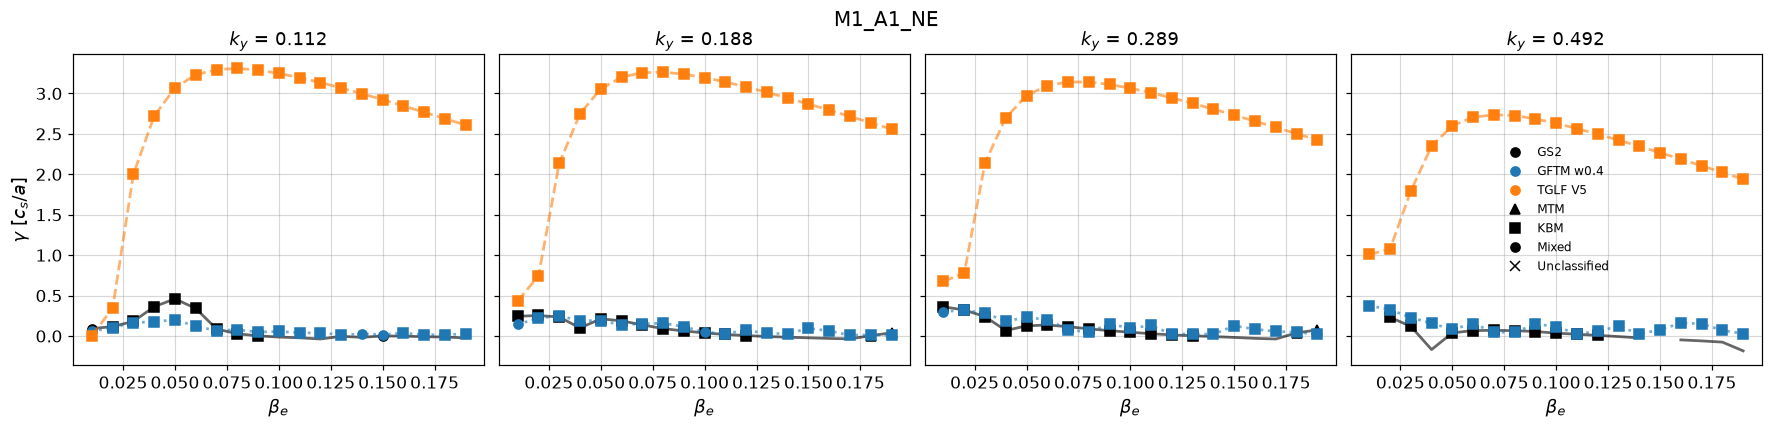

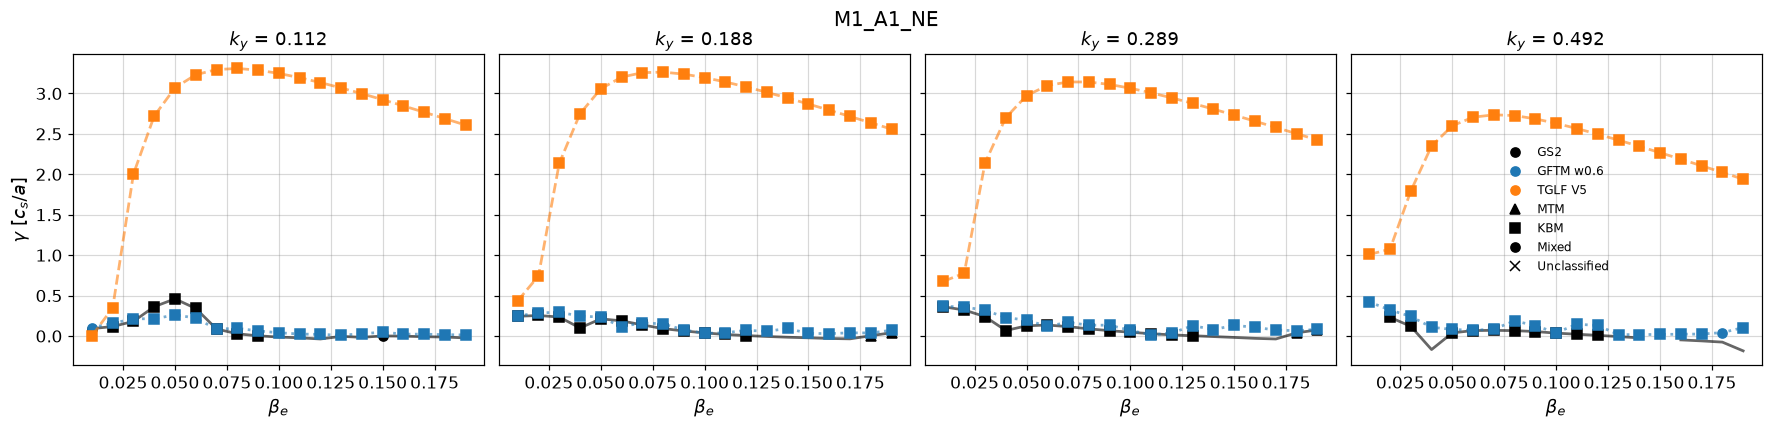

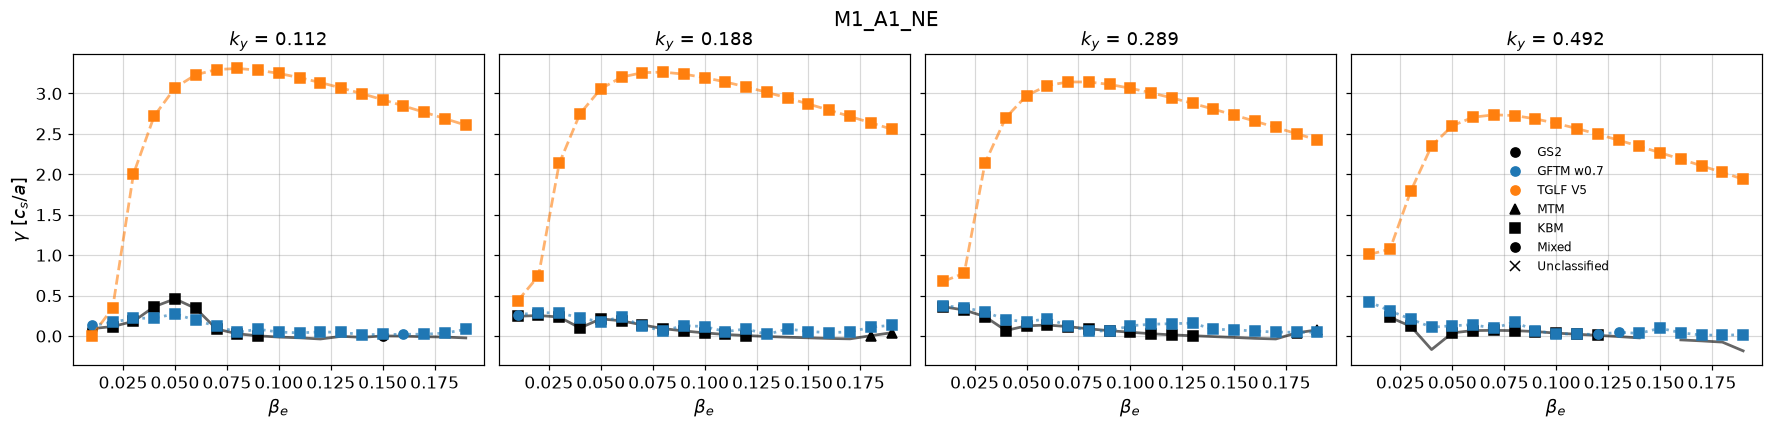

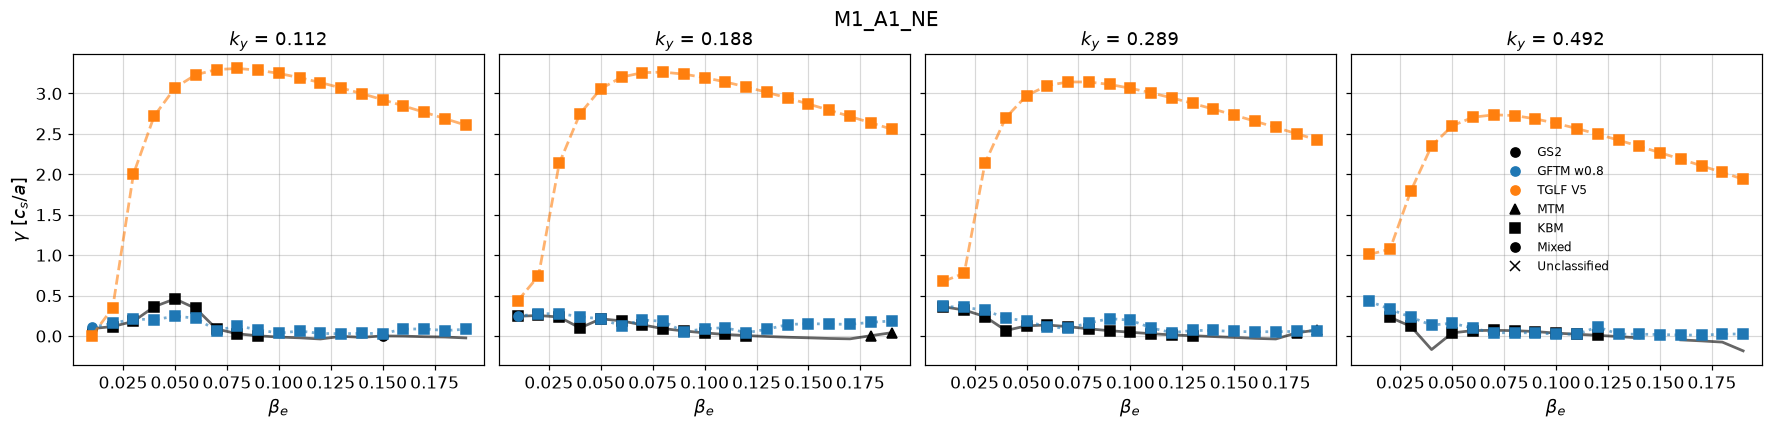

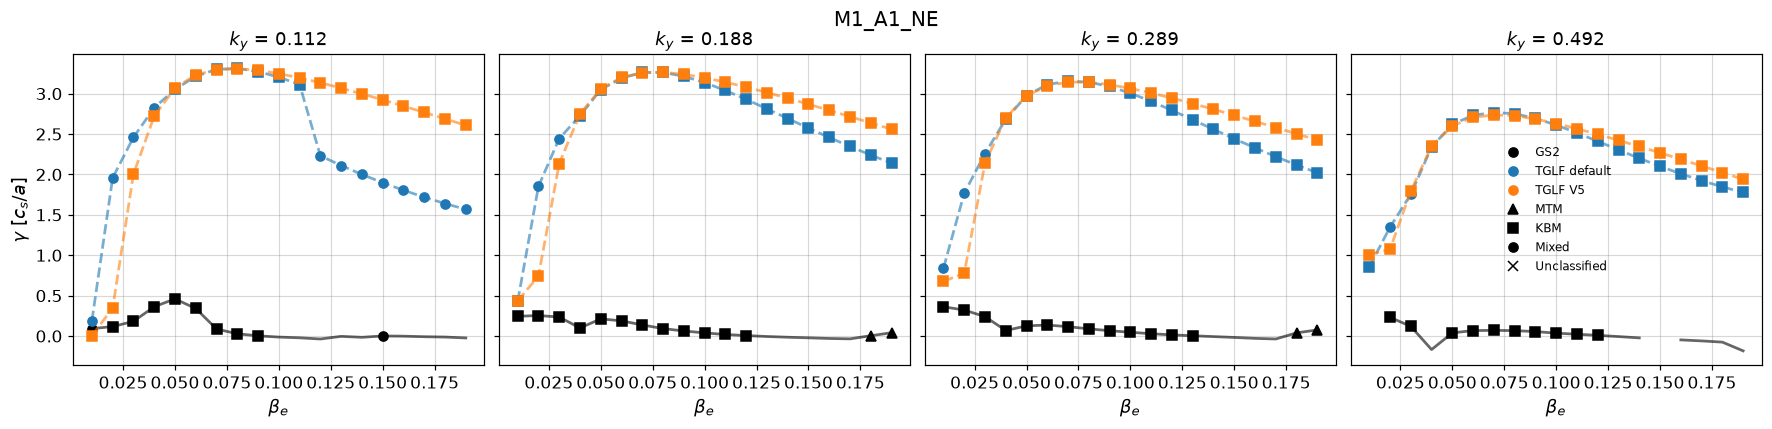

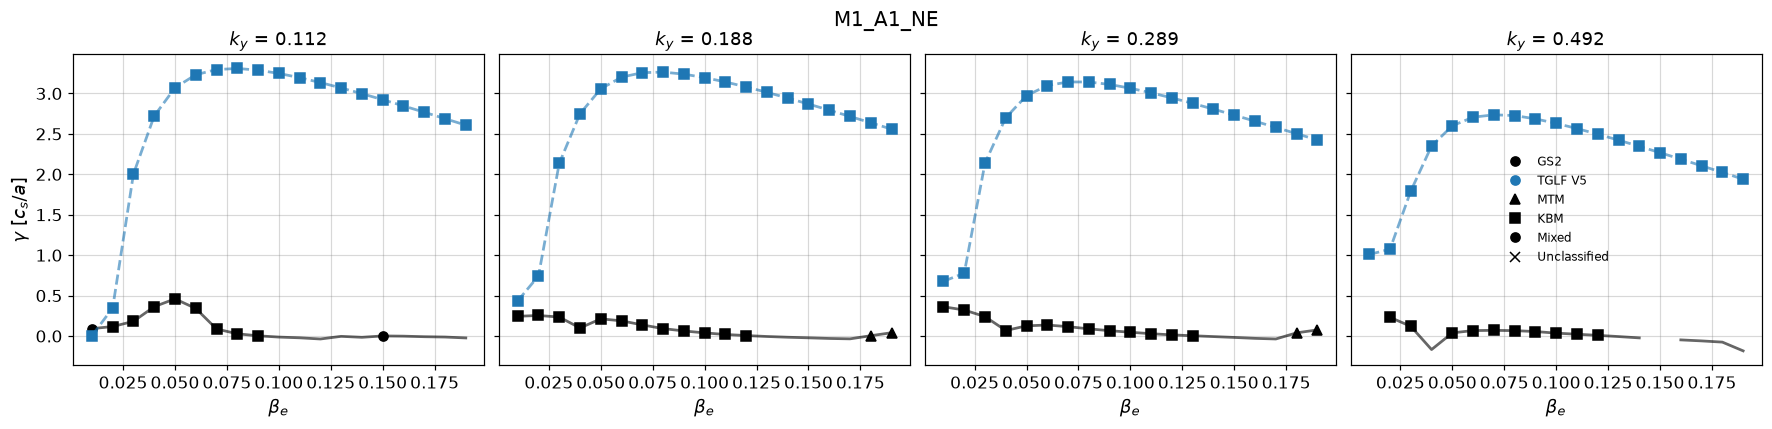

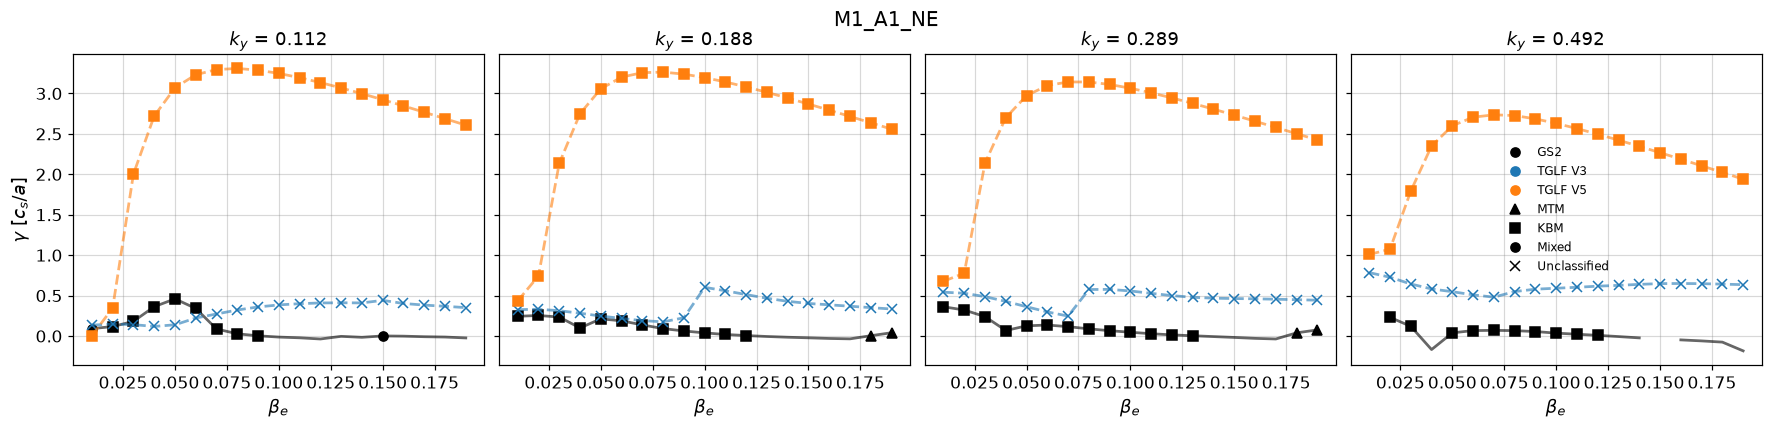

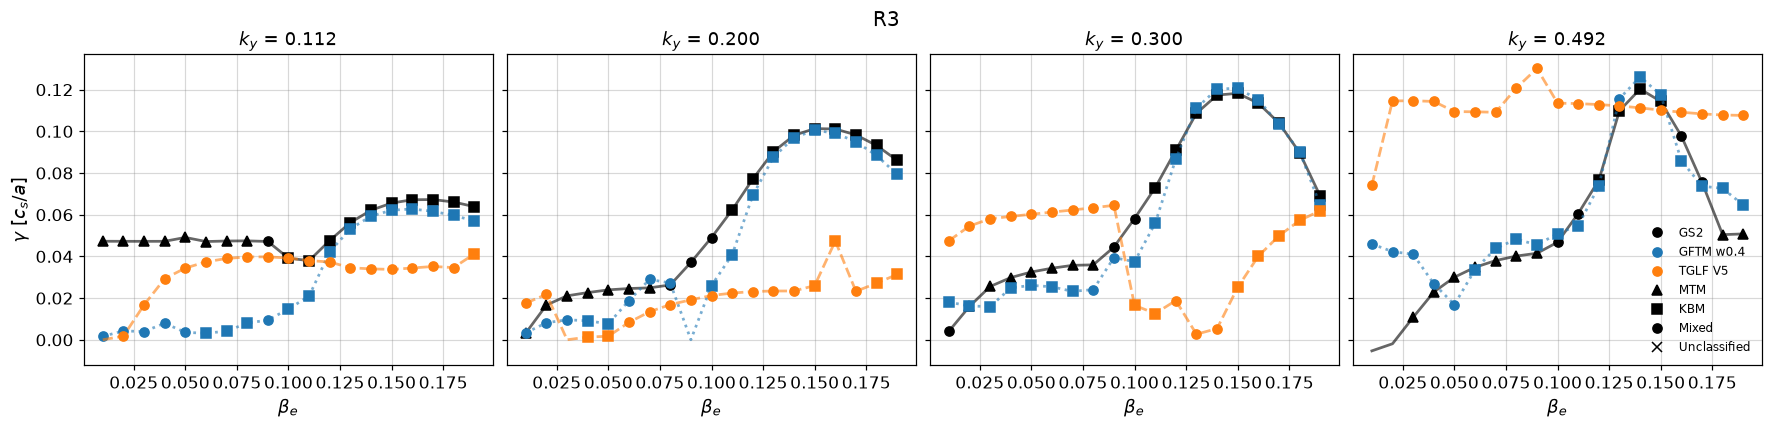

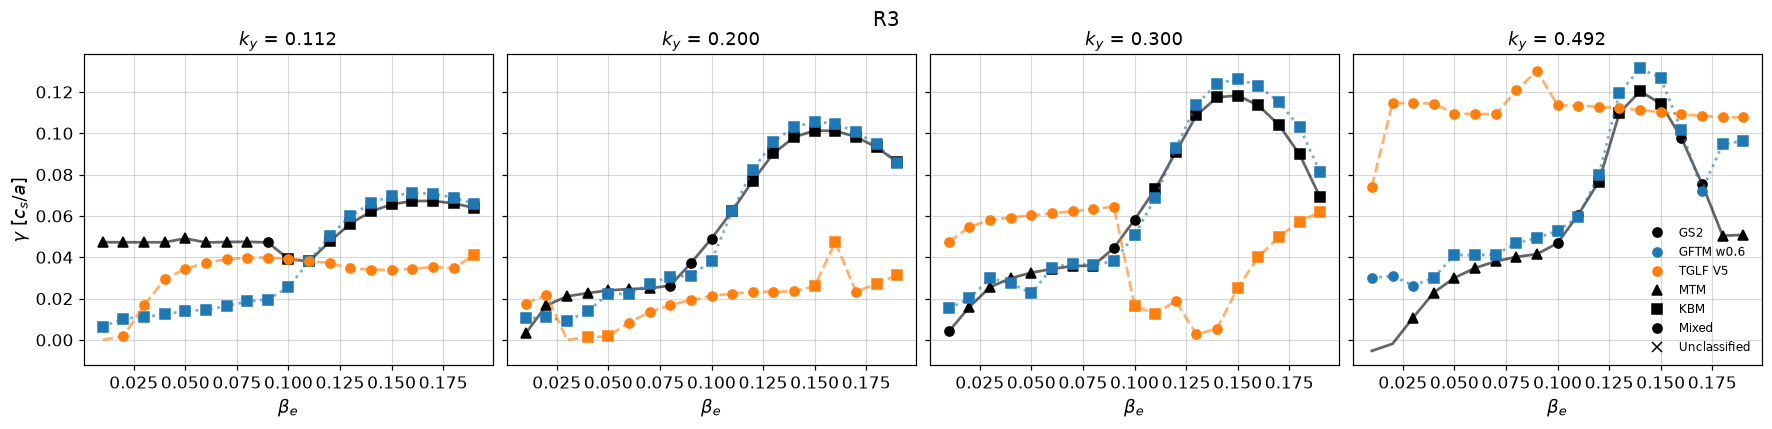

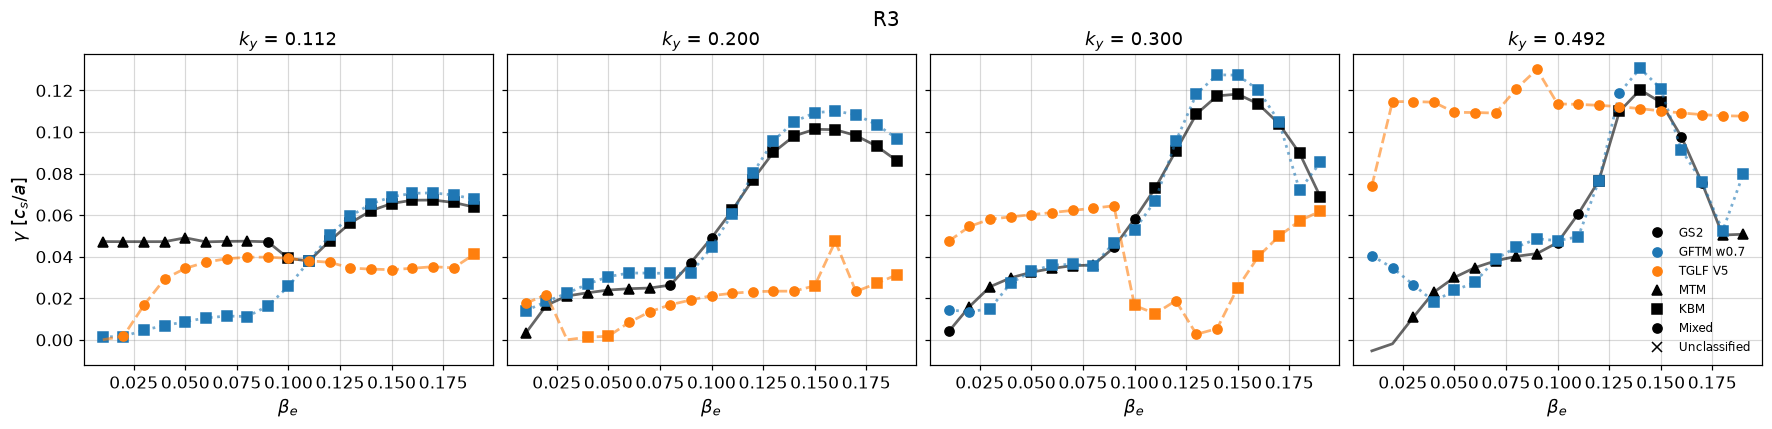

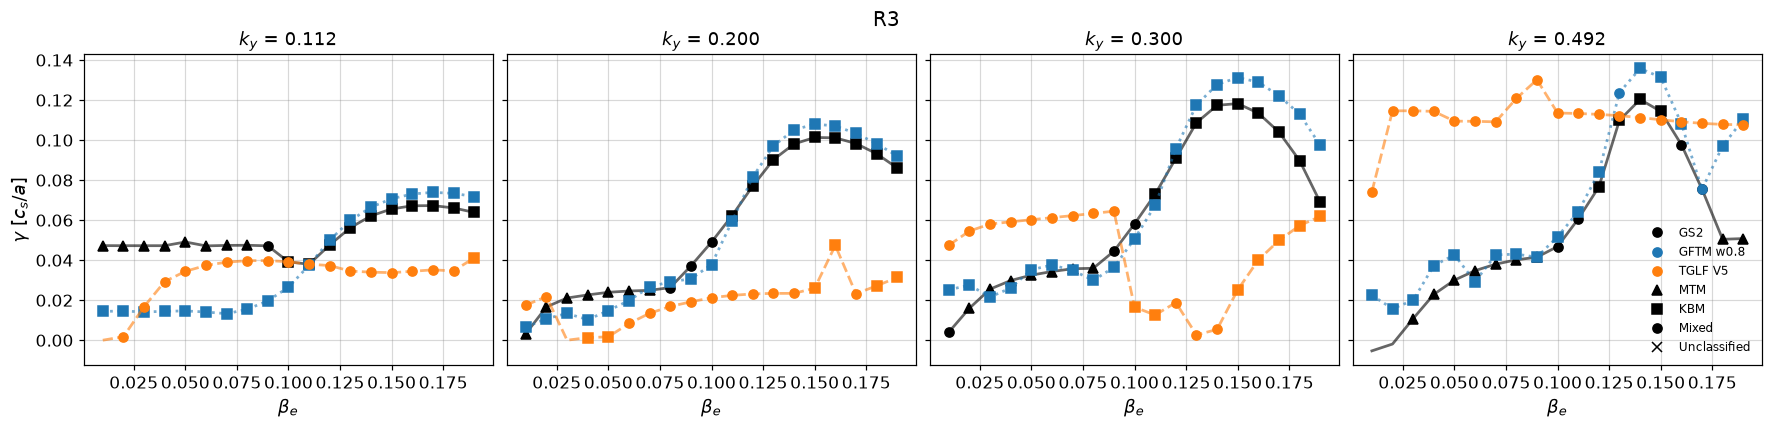

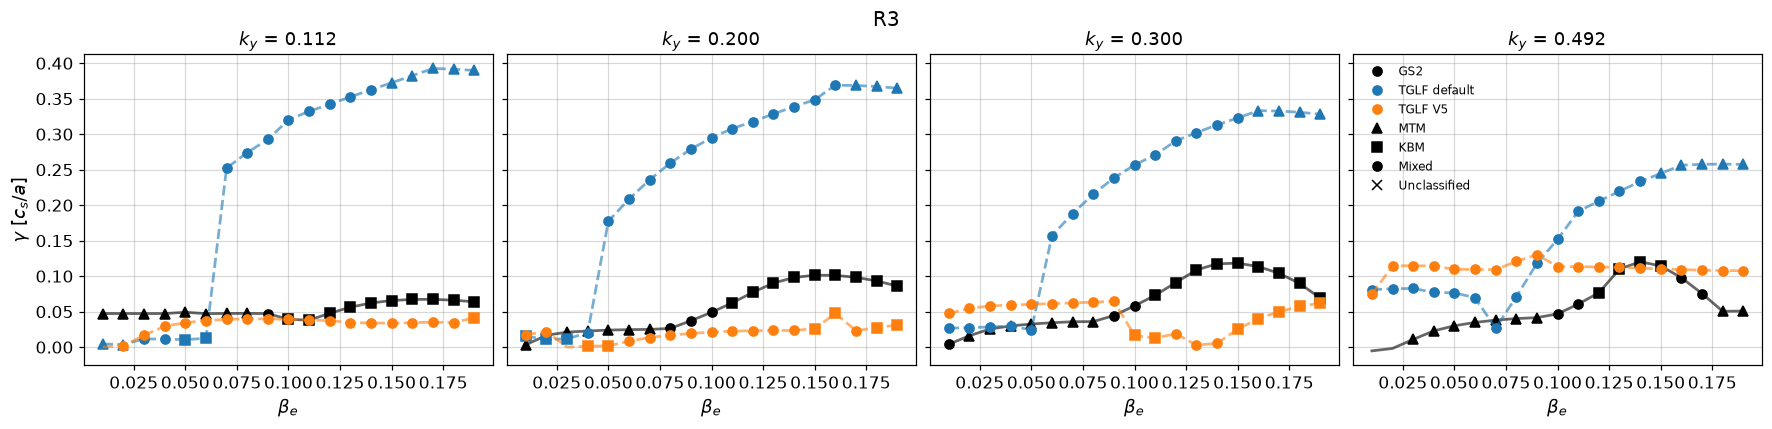

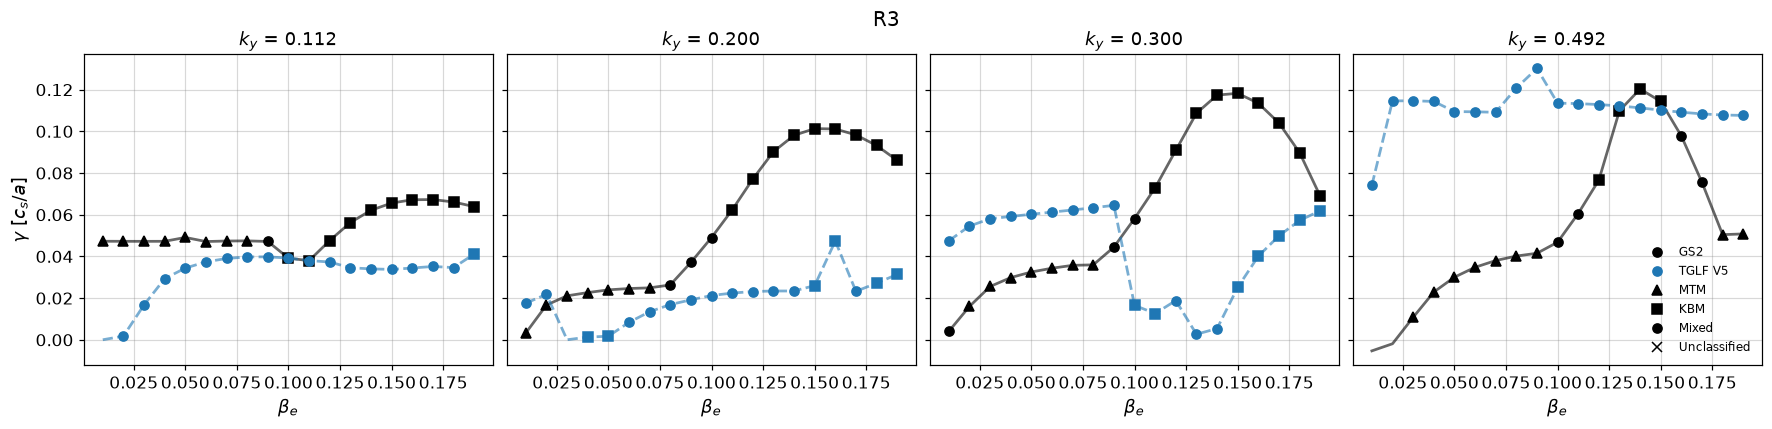

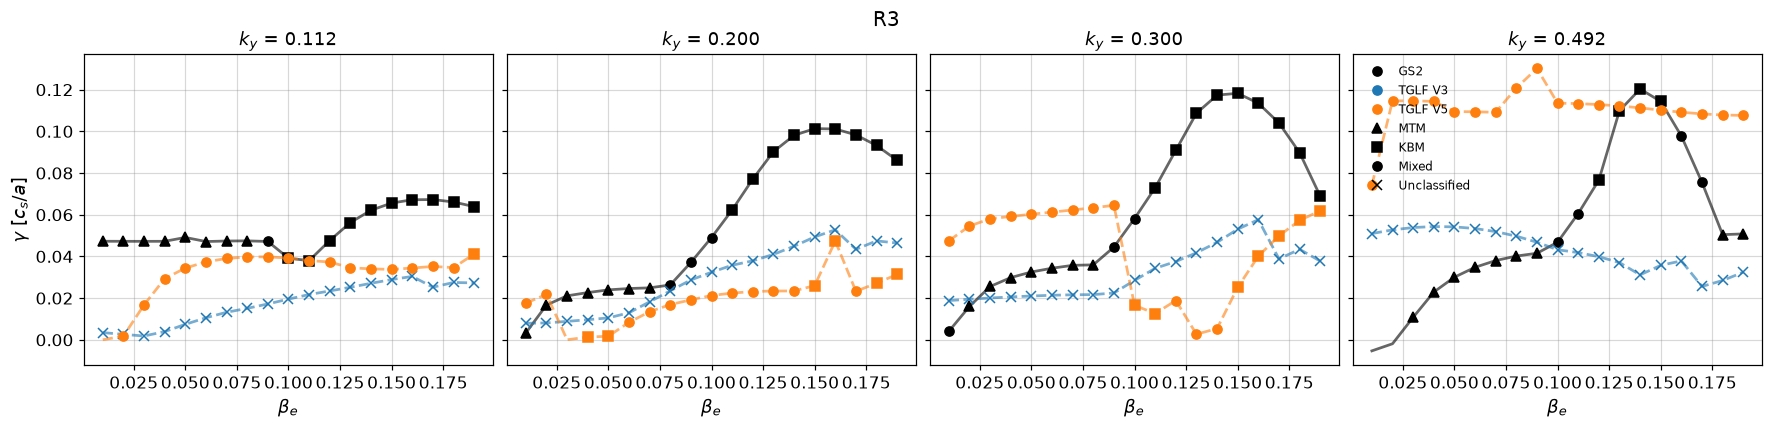

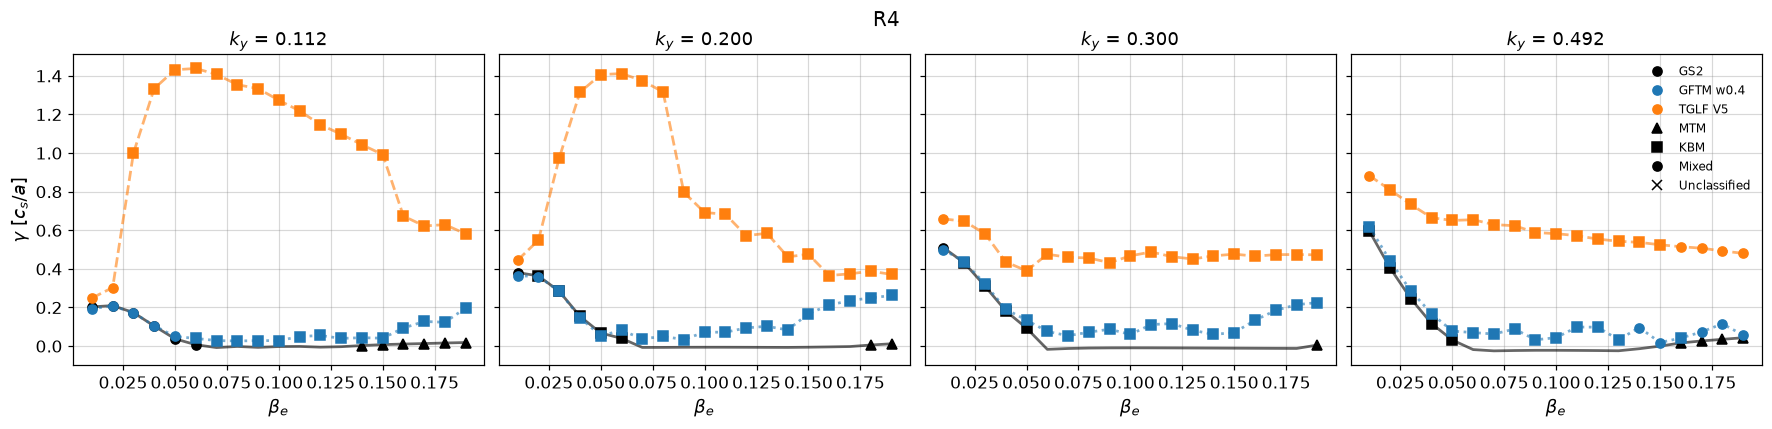

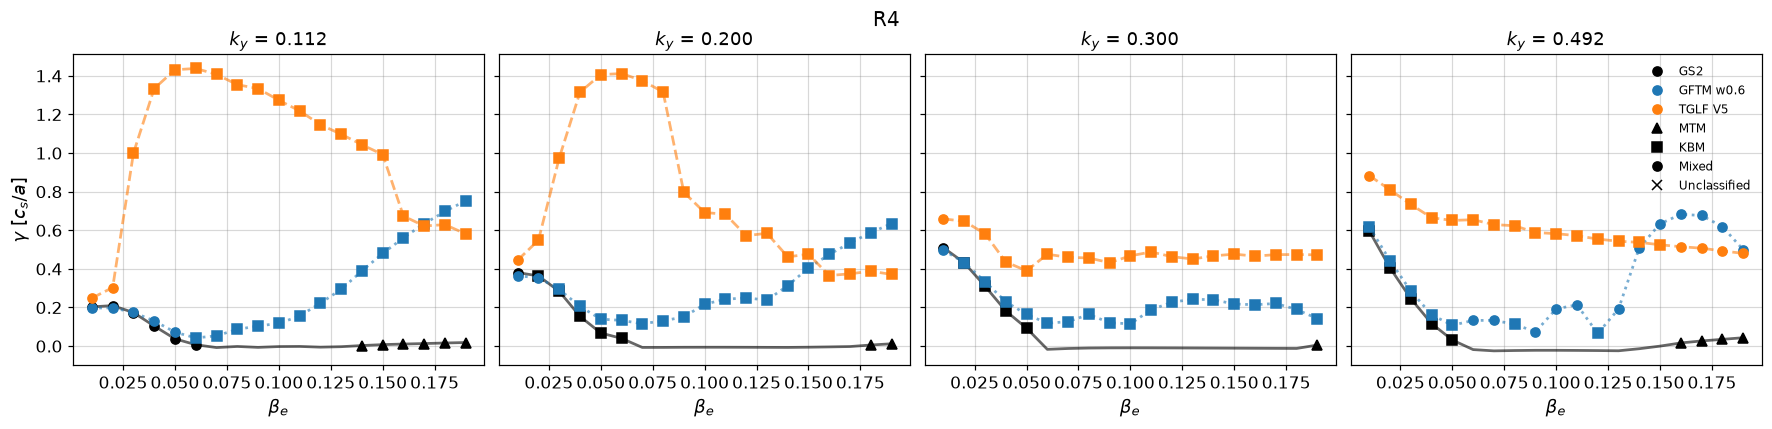

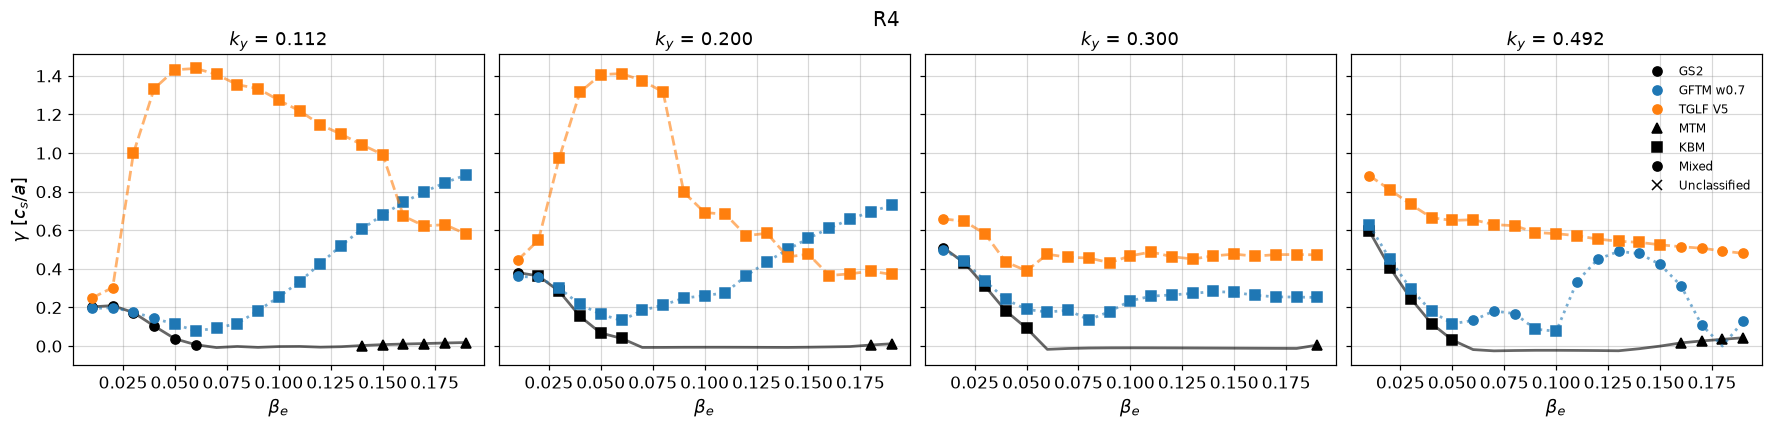

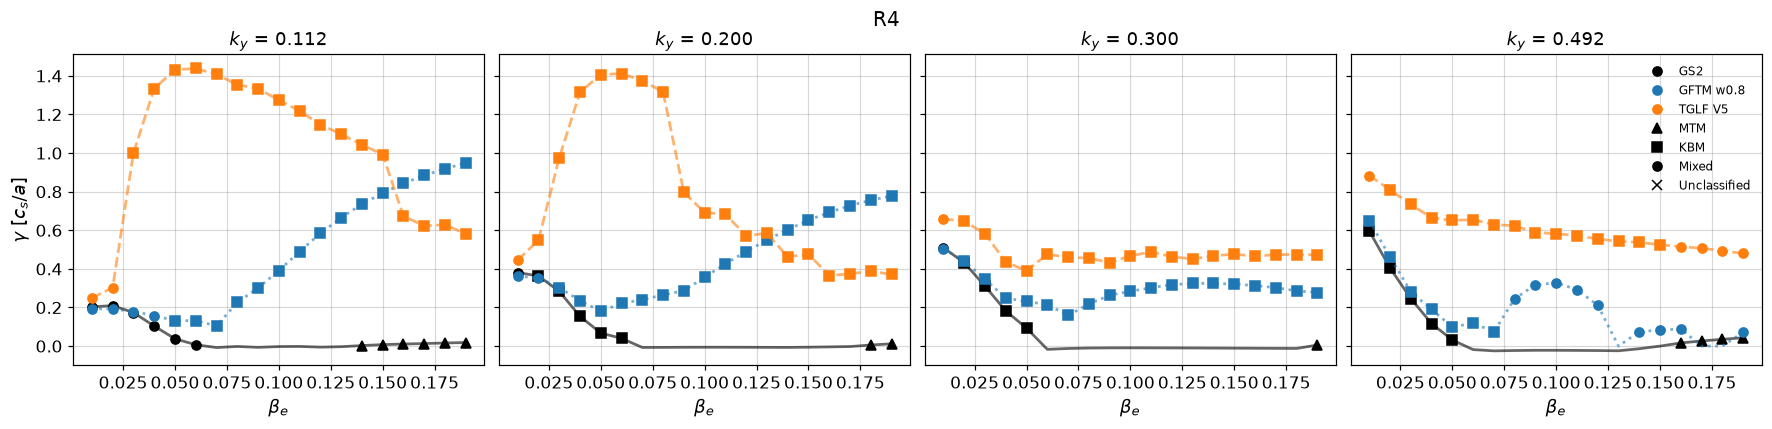

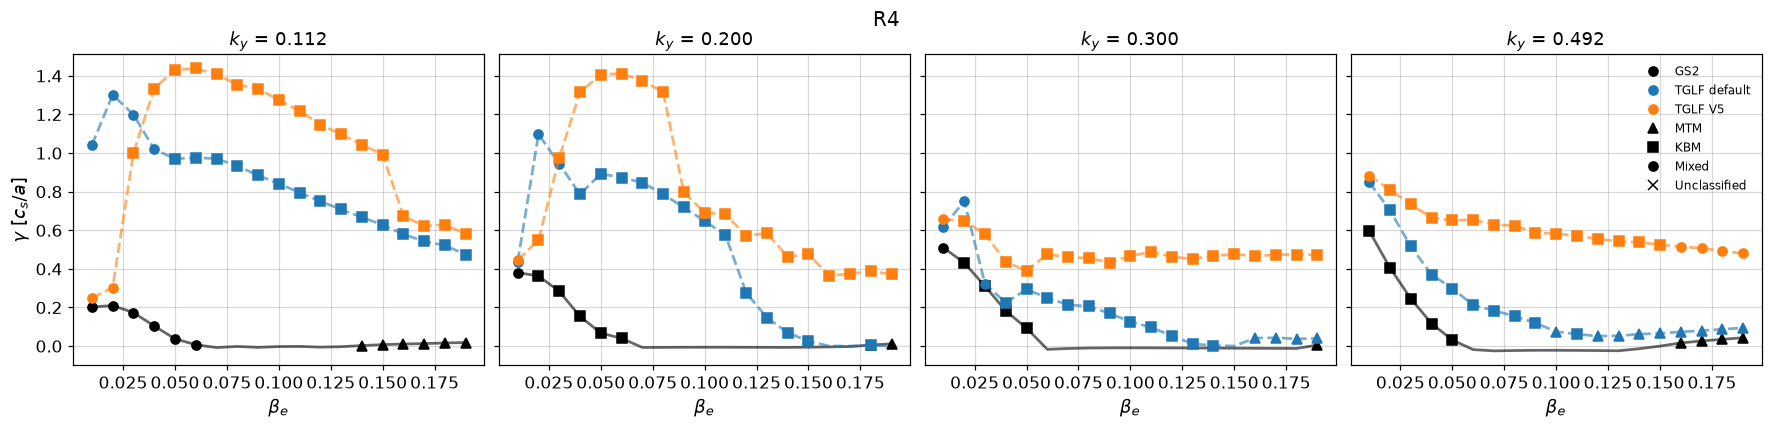

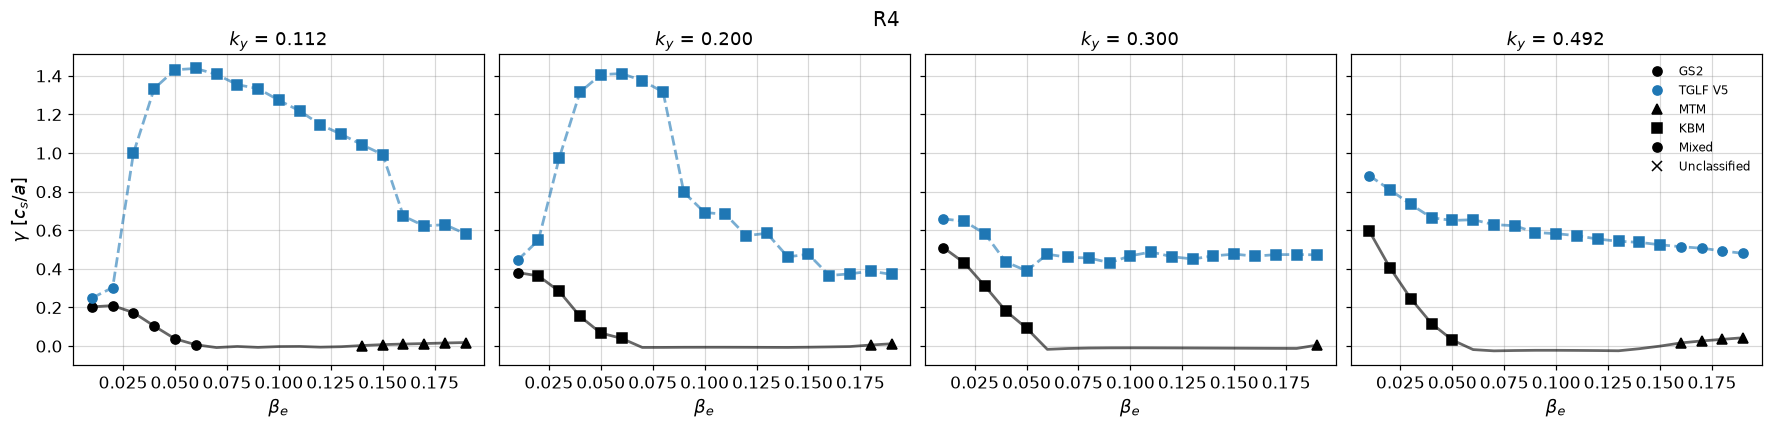

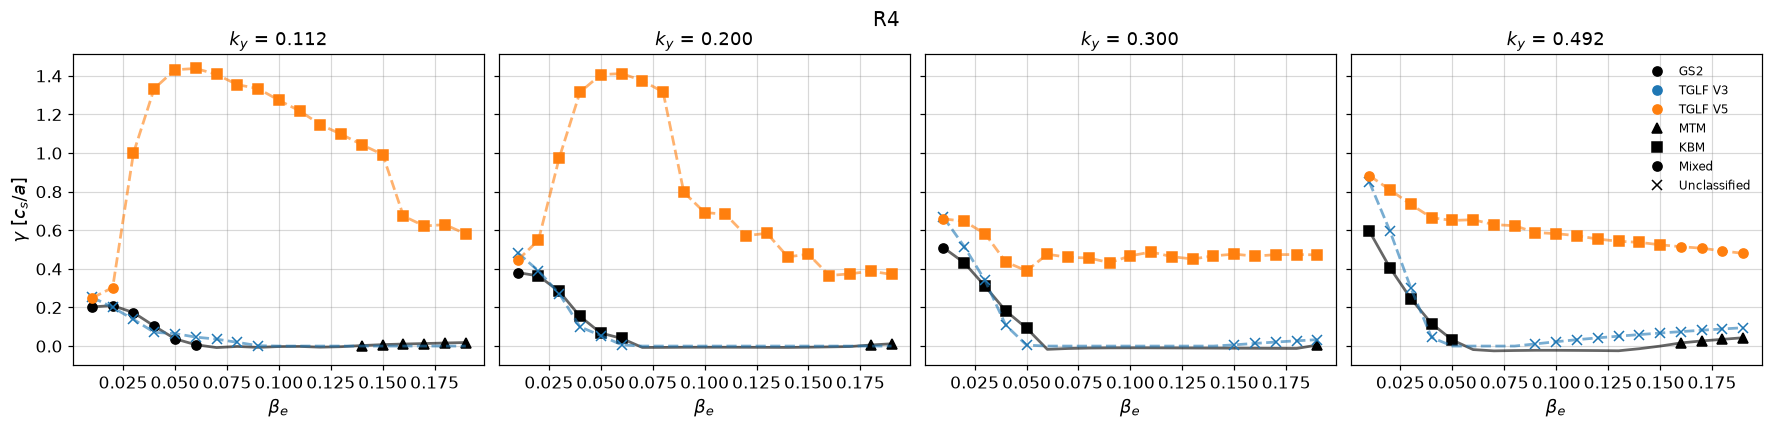

In [31]:
show_subdominant = False   # also draw each code's other mode (faint line, open markers)
comparison = "TGLF V5"     # drawn in every figure next to the code
marker = {"MTM": "^", "KBM": "s", "mixed": "o", "unclassified": "x"}   # unclassified: TGLF V3, no tearing_parameter
line_style = {"GFTM": ":", "TGLF": "--"}   # by code family, from the label prefix
figs = {}
for c in cases:
    ref, beta = gs2[c], gs2[c].beta.values
    jb = np.arange(beta.size)
    for lab in codes:
        series = [(lab, "C0")] + ([(comparison, "C1")] if lab != comparison else [])
        fig, axes = plt.subplots(1, len(ky_targets), figsize=(4 * len(ky_targets), 3.6), sharey=True)
        for ax, i in zip(axes, ky_index[c]):
            ax.plot(beta, ref.growth_rate.values[i], alpha=0.6, color="k", marker="none")
            for j, g in enumerate(ref.growth_rate.values[i]):
                if (c, i, j) in gs2_label:
                    ax.plot(beta[j], g, color="k", marker=marker[gs2_label[(c, i, j)]], ls="")
            for name, col in series:
                g, d, typ = model[(c, name)].growth_rate.values[i], dominant_mode[(c, name)][i], code_label[(c, name)][i]
                ls = line_style[name.split()[0]]
                ax.plot(beta, g[jb, d], color=col, ls=ls, alpha=0.6, marker="none")
                if show_subdominant:
                    ax.plot(beta, g[jb, 1 - d], color=col, ls=ls, alpha=0.4, marker="none")   # NMODES = 2
                for j, m in np.argwhere(g > gamma_floor):
                    if m == d[j] or show_subdominant:
                        ax.plot(beta[j], g[j, m], color=col, marker=marker[typ[j, m]], ls="", mfc=col if m == d[j] else "none")
            ax.set(xlabel=r"$\beta_e$", title=rf"$k_y$ = {float(ref.ky[i]):.3f}")
        key = [Line2D([], [], color="k", ls="", marker="o", label="GS2"),
               *[Line2D([], [], color=col, ls="", marker="o", label=name) for name, col in series],
               *([Line2D([], [], color="grey", alpha=0.4, label="other mode")] if show_subdominant else []),
               *[Line2D([], [], color="k", ls="", marker=m, label=t if t.isupper() else t.capitalize()) for t, m in marker.items()]]
        axes[0].set_ylabel(r"$\gamma$ [$c_s/a$]")
        axes[-1].legend(handles=key, loc="best", fontsize=8)
        fig.suptitle(rf"{c}", y=1.04)
        figs[(c, lab)] = fig
print(len(figs), "figures")
plt.show()


In [34]:
ky_comparisons = {"TGLF default": "C1", "TGLF V3": "C2"}   # all drawn in every single-ky figure
ky_codes = [lab for lab in codes if lab != "TGLF V5"]   # TGLF V5 left out of the single-ky figures
legend_name = {"GFTM w0.4": "GFTM"}   # display name in the single-ky legends; other labels unchanged
figs_ky = {}   # one figure per (case, code, ky); same lines and markers as the panel figures above
for c in cases:
    ref, beta = gs2[c], gs2[c].beta.values
    jb = np.arange(beta.size)
    for lab in ky_codes:
        series = ([] if lab in ky_comparisons else [(lab, "C0")]) + list(ky_comparisons.items())
        key = [Line2D([], [], color="k", ls="", marker="o", label="GS2"),
               *[Line2D([], [], color=col, ls="", marker="o", label=legend_name.get(name, name)) for name, col in series],
               *([Line2D([], [], color="grey", alpha=0.4, label="other mode")] if show_subdominant else []),
               *[Line2D([], [], color="k", ls="", marker=m, label=t if t.isupper() else t.capitalize()) for t, m in marker.items()]]
        for i in ky_index[c]:
            fig, ax = plt.subplots(figsize=(5, 3.8))
            ax.plot(beta, ref.growth_rate.values[i], alpha=0.6, color="k", marker="none")
            for j, g in enumerate(ref.growth_rate.values[i]):
                if (c, i, j) in gs2_label:
                    ax.plot(beta[j], g, alpha=0.6, color="k", marker=marker[gs2_label[(c, i, j)]], ls="")
            for name, col in series:
                g, d, typ = model[(c, name)].growth_rate.values[i], dominant_mode[(c, name)][i], code_label[(c, name)][i]
                ls = line_style[name.split()[0]]
                ax.plot(beta, g[jb, d], alpha=0.6, color=col, ls=ls, marker="none")
                if show_subdominant:
                    ax.plot(beta, g[jb, 1 - d], color=col, ls=ls, alpha=0.4, marker="none")   # NMODES = 2
                for j, m in np.argwhere(g > gamma_floor):
                    if m == d[j] or show_subdominant:
                        ax.plot(beta[j], g[j, m], alpha=0.6, color=col, marker=marker[typ[j, m]], ls="", mfc=col if m == d[j] else "none")
            ky = float(ref.ky[i])
            ax.set(xlabel=r"$\beta_e$", ylabel=r"$\gamma$ [$c_s/a$]", title=rf"{c}, $k_y$ = {ky:.3f}")
            ax.legend(handles=key, loc="best", fontsize=8)
            figs_ky[(c, lab, ky)] = fig
            plt.close(fig)   # too many to display, check the saved PNGs
print(len(figs_ky), "figures")
plt.show()


72 figures


## Save

In [35]:
output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)
for (c, lab), fig in figs.items():
    fig.savefig(output_dir / f"{c}_{lab.replace(' ', '_').replace('.', 'p')}.png", dpi=150, bbox_inches="tight")
for (c, lab, ky), fig in figs_ky.items():
    fig.savefig(output_dir / f"{c}_{lab.replace(' ', '_').replace('.', 'p')}_ky{ky:.3f}.png", dpi=150, bbox_inches="tight")
print("saved", len(figs), "panel and", len(figs_ky), "single-ky figures to", output_dir)

saved 21 panel and 72 single-ky figures to /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/Plots/beta_stabilisation_f05


## Marker spot check

**Code leaves**: T recomputed with pyro's `FieldLine.compute_linear_tearing_parameter` from each leaf's stored A∥
eigenfunction, against the stored `tearing_parameter` (T is scale-free, so the normalised eigenfunction gives the same
T). **GS2 cells**: three random plotted cells per case (seed above, gamma > 0) with the full indicator set and the label
it produced.

In [9]:
rng = np.random.default_rng(seed)

def eig_T(pyroscan):
    "FieldLine T of every (ky, beta, mode) from the scan's stored A_par eigenfunction"
    p = pyroscan.base_pyro
    p.gk_output = xr.Dataset({"apar": pyroscan.gk_output.data.eigenfunctions.sel(field="apar")})
    return FieldLine(p).compute_linear_tearing_parameter().transpose("ky", "beta", "mode").values

print("CODE leaves: max |stored T - recomputed T|")
for (c, lab), ds in model.items():
    print(f"{c:9s} {lab:13s} {np.nanmax(np.abs(eig_T(model_pyroscan[(c, lab)]) - ds.tearing_parameter.values)):.1e}")

print("GS2 cells: T, omega, chi_e/chi_i, De/chi_e -> label")
for c in cases:
    cand = [k for k in gs2_label if k[0] == c]
    for k in rng.choice(len(cand), n_spot, replace=False):
        _, i, j = cand[k]
        ind = gs2_indicators(c, i, j)
        print(f"{c:9s} GS2 ky={float(gs2[c].ky[i]):.3f} beta={float(gs2[c].beta[j]):.2f}  "
              + "  ".join(f"{n} {ind[n]:+.3f}" for n in ("T", "omega", "chi_ratio", "de_chi")) + f"  -> {mc.classify(ind)}")


CODE leaves: max |stored T - recomputed T|


M1_A1_NE  GFTM w0.4     2.9e-16
M1_A1_NE  GFTM w0.6     2.6e-16
M1_A1_NE  GFTM w0.7     2.4e-16
M1_A1_NE  GFTM w0.8     2.2e-16
M1_A1_NE  TGLF default  1.4e-15
M1_A1_NE  TGLF V5       2.2e-16
R3        GFTM w0.4     2.5e-16
R3        GFTM w0.6     2.9e-16
R3        GFTM w0.7     2.9e-16
R3        GFTM w0.8     2.9e-16
R3        TGLF default  1.3e-15
R3        TGLF V5       2.7e-16
R4        GFTM w0.4     2.0e-16
R4        GFTM w0.6     2.6e-16
R4        GFTM w0.7     2.0e-16
R4        GFTM w0.8     2.3e-16
R4        TGLF default  1.8e-15
R4        TGLF V5       2.8e-16
GS2 cells: T, omega, chi_e/chi_i, De/chi_e -> label


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


M1_A1_NE  GS2 ky=0.289 beta=0.07  T +0.000  omega +2.250  chi_ratio +0.509  de_chi +0.862  -> KBM
M1_A1_NE  GS2 ky=0.289 beta=0.02  T +0.000  omega +0.283  chi_ratio +0.667  de_chi +0.956  -> KBM
M1_A1_NE  GS2 ky=0.492 beta=0.02  T +0.000  omega +0.397  chi_ratio +0.698  de_chi +1.043  -> KBM
R3        GS2 ky=0.112 beta=0.02  T +0.890  omega -0.141  chi_ratio -0.107  de_chi -6.866  -> MTM


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


R3        GS2 ky=0.112 beta=0.06  T +0.723  omega -0.139  chi_ratio -0.126  de_chi -7.012  -> MTM
R3        GS2 ky=0.112 beta=0.03  T +0.839  omega -0.138  chi_ratio -0.093  de_chi -6.899  -> MTM
R4        GS2 ky=0.300 beta=0.02  T +0.000  omega +0.088  chi_ratio +1.056  de_chi +0.667  -> KBM
R4        GS2 ky=0.200 beta=0.06  T +0.000  omega +0.179  chi_ratio +1.048  de_chi +0.466  -> KBM
R4        GS2 ky=0.492 beta=0.16  T +0.676  omega -2.597  chi_ratio +103.413  de_chi +0.006  -> MTM


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Interpretation

Left to the reader. Code-side markers use T and ω only (no flux weights), GS2 markers use all four indicators, so a
GS2 "mixed" next to a code "KBM" can be a difference in the test rather than in the physics.

## R4 at high β: why GFTM predicts a strong KBM where GS2 is near marginal (Fusion_PhD-38e9.9)

Above β ≈ 0.07 (GS2 number) GS2's dominant R4 mode at ky ≈ 0.1–0.3 is near marginal, while every GFTM width
predicts a growing ballooning-parity mode, more strongly the larger WIDTH is. This section compares the two at the
level of the mode itself. Every leaf is a `PyroScan` loaded from its `pyroscan.nc`, with pyro's `Extent` (95% of
∫|field|²dθ) added to its `gk_output`. Per-run `Pyro` reads remain only for GS2 γ(t) (not stored in a scan) and the
input decks of the β′ and ideal-ballooning checks. Dominant mode = `argmax` of γ over `mode`.

Leaves: GFTM `scan_beta_f05/R4/w0p{4,6,7,8}` (FILTER 0.5) and `scan_beta/R4/parameter_scan_gftm_default`
(WIDTH 1.74, otherwise the same deck: FIND_WIDTH=F, FILTER 0.5, NBASIS_MAX 12, NXGRID 32, NMODES 2, USE_BPAR=T).
The 1.74 leaf labels β with GS2's number and ky to 3 decimals; it is matched by index (asserted below).
GS2 convergence: `growth_rate_tolerance` from GS2's `pyroscan.nc`, thresholds from Fusion_PhD-6vvq
(< 1e-2 converged, ≥ 1e-1 unconverged; unconverged GS2 points are drawn open).

In [10]:
from pyrokinetics.diagnostics.extent import Extent
from matplotlib.ticker import StrMethodFormatter
import pandas as pd

r4 = "R4"
r4_codes = {   # label -> (code, project, leaf, WIDTH)
    "GFTM w0.4": ("GFTM", "scan_beta_f05", "w0p4", 0.4),
    "GFTM w0.6": ("GFTM", "scan_beta_f05", "w0p6", 0.6),
    "GFTM w0.7": ("GFTM", "scan_beta_f05", "w0p7", 0.7),
    "GFTM w0.8": ("GFTM", "scan_beta_f05", "w0p8", 0.8),
    "GFTM w1.74": ("GFTM", "scan_beta", "parameter_scan_gftm_default", 1.74),
}
r4_eig = ["GFTM w0.4", "GFTM w0.8", "GFTM w1.74"]   # widths drawn in the eigenfunction figures
r4_ky = [0.1, 0.2, 0.3]                            # snapped to GS2's grid
beta_high, beta_low = 0.15, 0.02                   # GS2 beta numbers: the high-beta cells and the control
tol_unconverged = 1e-1
fraction = 0.95
fields = ["phi", "apar", "bpar"]
field_label = {"phi": r"$\phi$", "apar": r"$A_\parallel$", "bpar": r"$B_\parallel$"}
colour = {lab: plt.cm.viridis(x) for lab, x in zip(r4_codes, np.linspace(0, 0.9, len(r4_codes)))}


def v(da):
    return np.asarray(getattr(da.data, "magnitude", da.data))


def load_r4(code, project, leaf):
    s = scan(code, project, r4, leaf)
    Extent(s.gk_output, fraction=fraction)
    return s


r4_pyroscan = {"GS2": load_r4(gs2_code, gs2_project, gs2_scan)}
r4_pyroscan |= {lab: load_r4(*spec[:3]) for lab, spec in r4_codes.items()}
R = {lab: s.gk_output.data for lab, s in r4_pyroscan.items()}
for lab, d in R.items():
    assert np.allclose(v(d.ky), v(R["GS2"].ky), atol=1e-3) and d.beta.size == R["GS2"].beta.size, lab


def dominant(d, name):
    "variable of the dominant (argmax gamma over mode) mode; GS2 has one mode"
    if "mode" not in d[name].dims:
        return d[name]
    m = np.nan_to_num(v(d.growth_rate), nan=-np.inf).argmax(-1)
    return d[name].isel(mode=xr.DataArray(m, dims=("ky", "beta")))


beta_r4 = gs2[r4].beta.values            # GS2's numbers, the x axis throughout
iky = [int(np.abs(gs2[r4].ky.values - k).argmin()) for k in r4_ky]
jhi, jlo = (int(np.abs(beta_r4 - b).argmin()) for b in (beta_high, beta_low))
tol = v(R["GS2"].growth_rate_tolerance)
print("ky:", [round(float(gs2[r4].ky[i]), 3) for i in iky], "| beta high", beta_r4[jhi], "control", beta_r4[jlo])

ky: [0.112, 0.2, 0.3] | beta high 0.15 control 0.02


### Where GFTM over-predicts

Dominant γ per code at the plotted ky for β ≥ 0.07, with GS2's tolerance. The eigenfunction cells are the high-β
cells at ky ≈ 0.11 and 0.2 and the low-β control at ky ≈ 0.2, where the codes agree.

In [11]:
g = {lab: v(dominant(d, "growth_rate")) for lab, d in R.items()}
rows = [{"ky": round(float(gs2[r4].ky[i]), 3), "beta": beta_r4[j], "GS2 tol": tol[i, j],
         **{lab: g[lab][i, j] for lab in R}} for i in iky for j in range(beta_r4.size) if beta_r4[j] >= 0.07]
with pd.option_context("display.float_format", "{:.3g}".format, "display.width", 200):
    print(pd.DataFrame(rows).to_string(index=False))

cells = {"control": (iky[1], jlo), "high, ky 0.11": (iky[0], jhi), "high, ky 0.2": (iky[1], jhi)}
for name, (i, j) in cells.items():
    print(f"{name}: ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[j]:.2f}  " + "  ".join(f"{lab} {g[lab][i, j]:+.3f}" for lab in R))

   ky  beta  GS2 tol      GS2  GFTM w0.4  GFTM w0.6  GFTM w0.7  GFTM w0.8  GFTM w1.74
0.112  0.07     1.06 -0.00781     0.0284     0.0532     0.0934      0.104       0.579
0.112  0.08      1.1 -0.00202     0.0264     0.0864      0.116      0.226       0.642
0.112  0.09     1.06 -0.00682     0.0283      0.104      0.184      0.301         0.7
0.112   0.1      1.9 -0.00263     0.0281      0.117      0.255      0.391       0.752
0.112  0.11     1.09 -0.00191     0.0494      0.156      0.334       0.49       0.798
0.112  0.12     1.19  -0.0057     0.0548      0.222      0.428      0.584       0.837
0.112  0.13     1.09 -0.00325     0.0397      0.294      0.521      0.665        0.87
0.112  0.14     1.23  0.00263     0.0434       0.39      0.606      0.735       0.898
0.112  0.15     1.57  0.00748     0.0407       0.48       0.68      0.793       0.921
0.112  0.16     1.91   0.0105     0.0937      0.561      0.745      0.842        0.94
0.112  0.17     3.08    0.013      0.127      0.634   

### (1) Eigenfunctions

Dominant mode of each code. Every field is divided by the complex φ at |φ|'s peak, so φ is real and 1 there and
A∥, B∥ keep their amplitude and phase relative to φ. Phase is drawn only where |field| > 1% of its own peak.

/scratch_local/ipykernel_1995052/2899336431.py:33: UserWarning: The figure layout has changed to tight
  fig_eig.tight_layout()
/scratch_local/ipykernel_1995052/2899336431.py:34: UserWarning: The figure layout has changed to tight
  fig_ph.tight_layout()


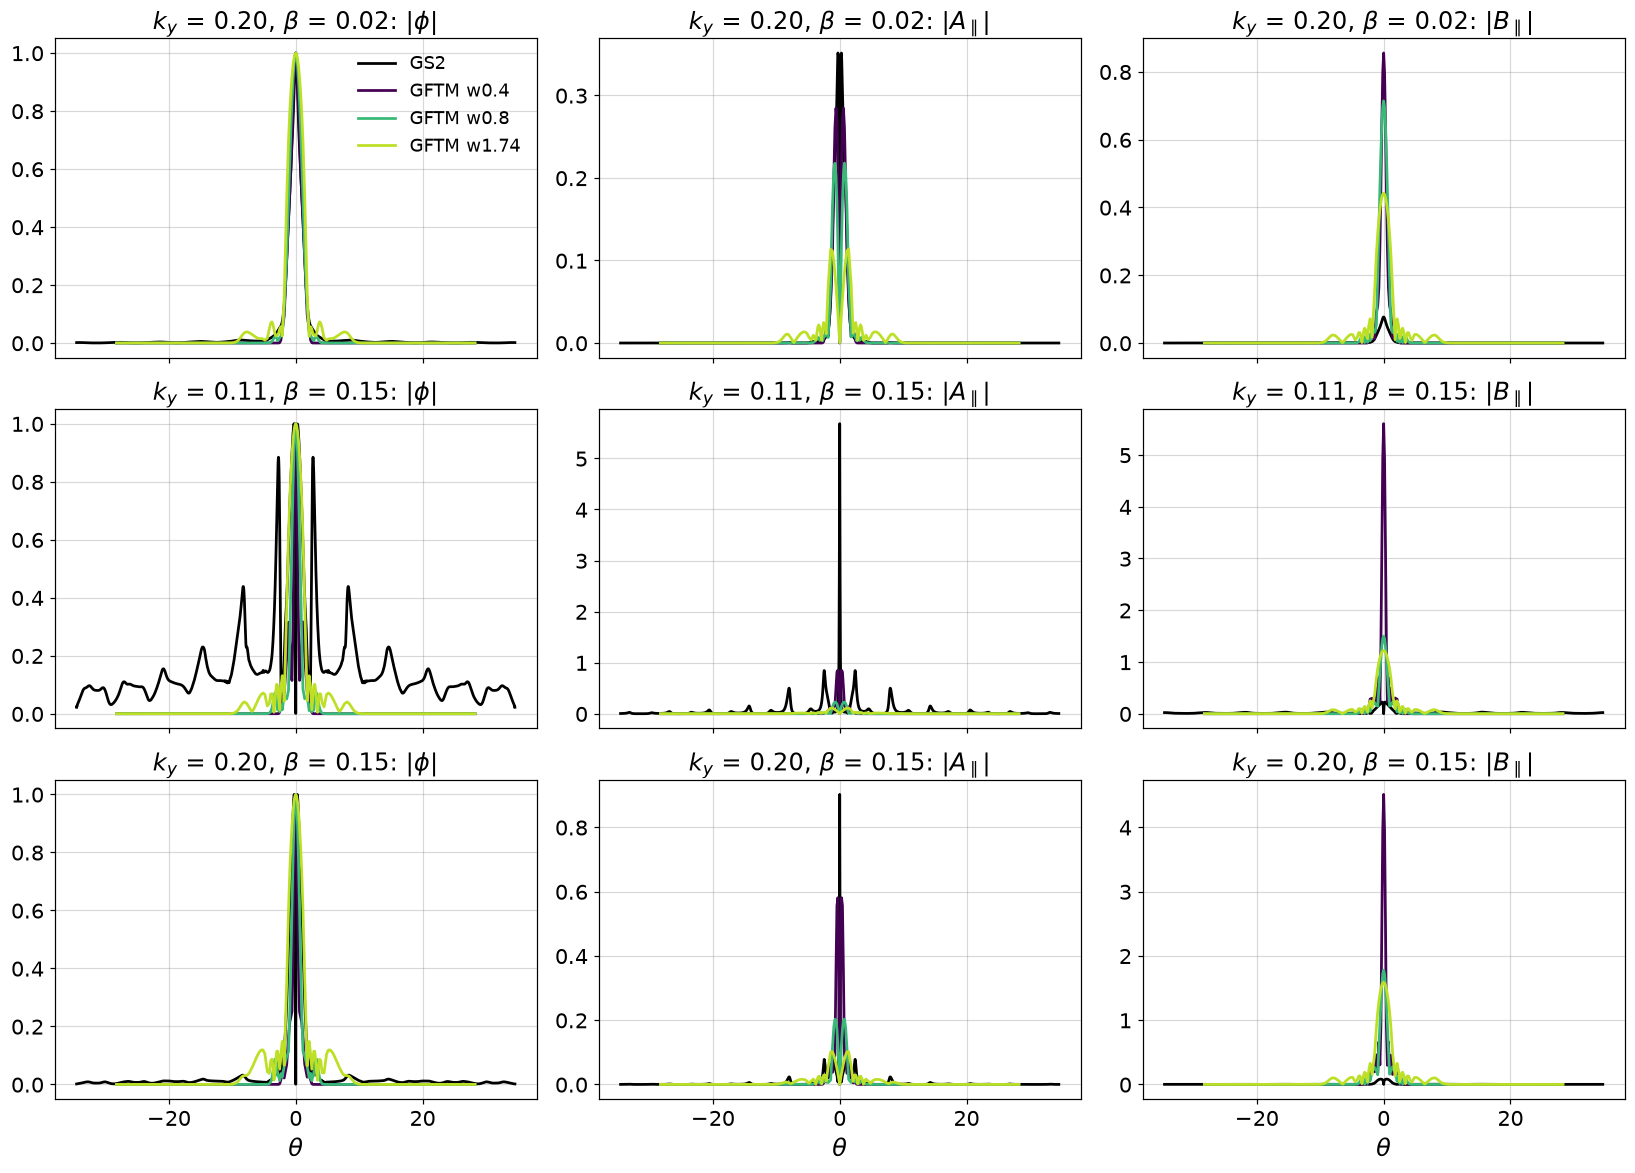

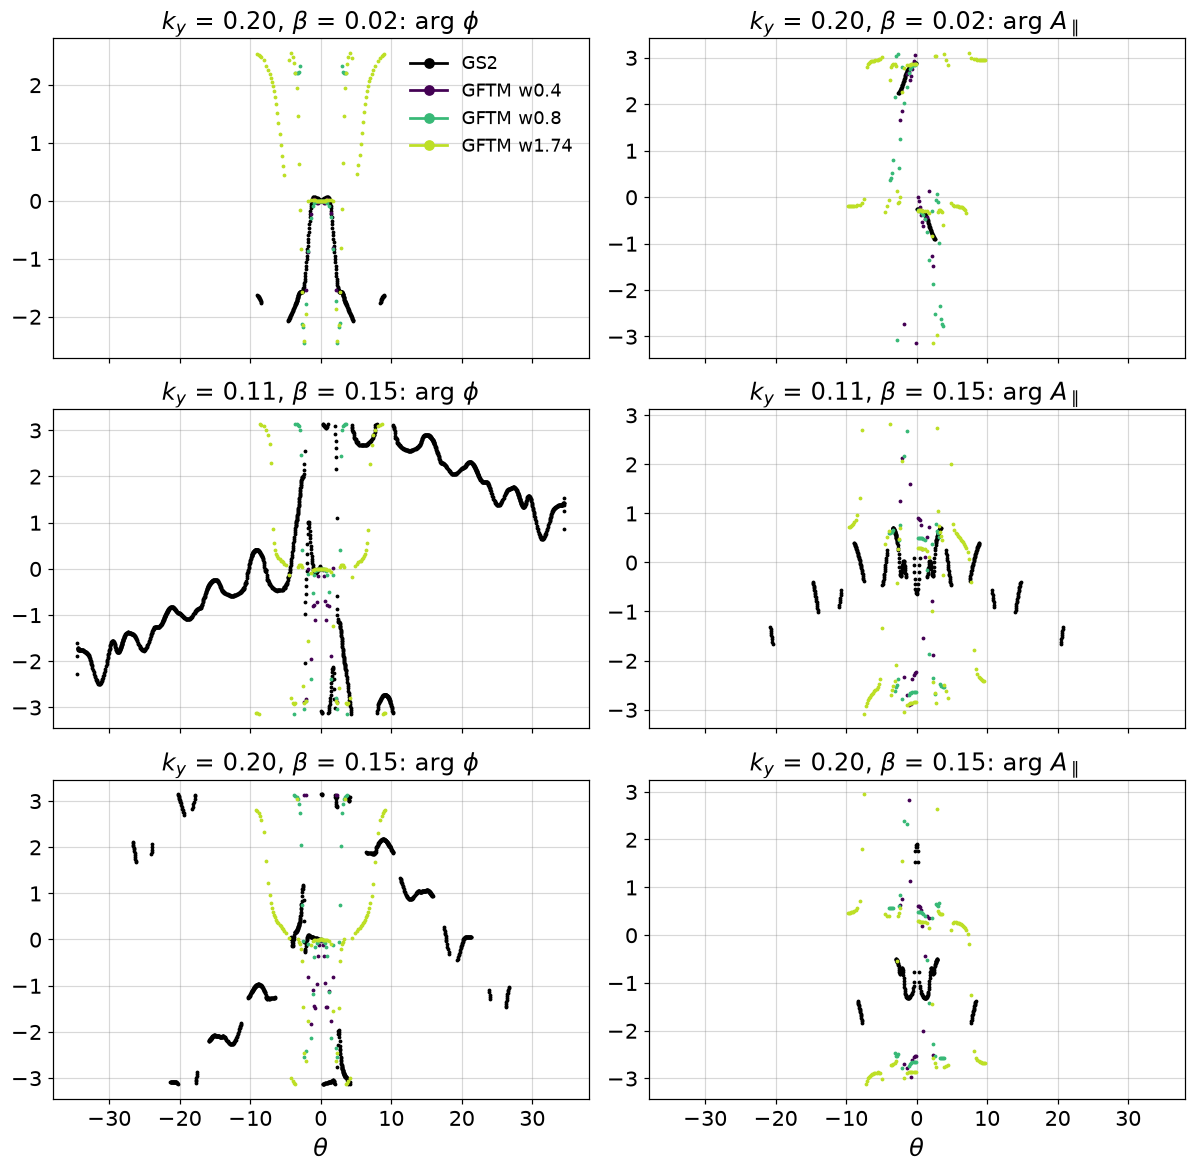

In [12]:
def eig(d, i, j):
    e = dominant(d, "eigenfunctions").isel(ky=i, beta=j)
    f = {k: v(e.sel(field=k)) for k in fields}
    p = f["phi"]
    norm = p[np.nanargmax(np.abs(p))]
    return v(e.theta), {k: x / norm for k, x in f.items()}


r4_eig_codes = ["GS2", *r4_eig]
line_colour = {"GS2": "k", **colour}
fig_eig, axes = plt.subplots(len(cells), len(fields), figsize=(15, 3.6 * len(cells)), sharex=True)
fig_ph, axes_ph = plt.subplots(len(cells), 2, figsize=(11, 3.6 * len(cells)), sharex=True)
for row, (name, (i, j)) in enumerate(cells.items()):
    for lab in r4_eig_codes:
        th, f = eig(R[lab], i, j)
        for col, k in enumerate(fields):
            axes[row, col].plot(th, np.abs(f[k]), color=line_colour[lab], label=lab, marker="none")
        for col, k in enumerate(("phi", "apar")):
            a = np.abs(f[k])
            ok = a > 0.01 * np.nanmax(a)
            axes_ph[row, col].plot(th[ok], np.angle(f[k][ok]), color=line_colour[lab], ls="", marker=".", ms=3)
    title = rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}, $\beta$ = {beta_r4[j]:.2f}"
    for col, k in enumerate(fields):
        axes[row, col].set_title(f"{title}: |{field_label[k]}|", fontsize=16)
    for col, k in enumerate(("phi", "apar")):
        axes_ph[row, col].set_title(f"{title}: arg {field_label[k]}", fontsize=16)
for ax in [*axes.flat, *axes_ph.flat]:
    ax.tick_params(labelsize=14)
for ax in [*axes[-1], *axes_ph[-1]]:
    ax.set_xlabel(r"$\theta$", fontsize=16)
axes[0, 0].legend(fontsize=12)
axes_ph[0, 0].legend(handles=[Line2D([], [], color=line_colour[l], label=l) for l in r4_eig_codes], fontsize=12)
fig_eig.tight_layout()
fig_ph.tight_layout()
plt.show()

### (2) Extents vs β

pyro `Extent` (θ range holding 95% of ∫|field|²dθ) of the dominant mode. Top: the extents themselves (grey dotted =
GS2's θ box, 2 × 34.6 rad; GFTM's wavefunction grid is ±28.3 rad). Bottom: log(Extent Ratio) = log₂(GFTM / GS2).

/scratch_local/ipykernel_1995052/488973952.py:32: UserWarning: The figure layout has changed to tight
  fig_ext.tight_layout()
/scratch_local/ipykernel_1995052/488973952.py:33: UserWarning: The figure layout has changed to tight
  fig_rat.tight_layout()


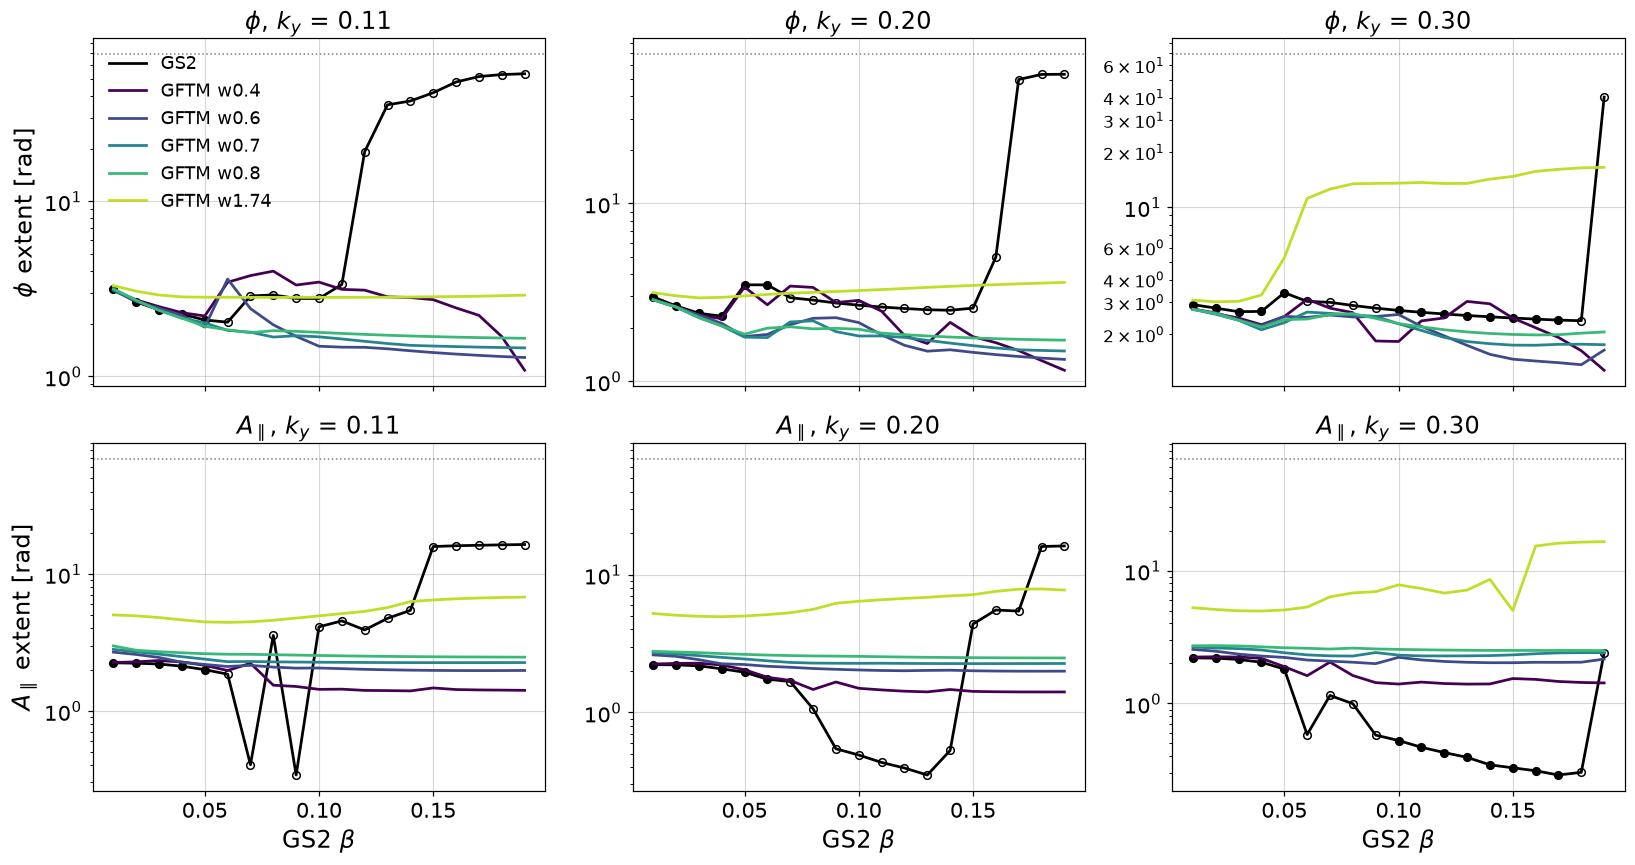

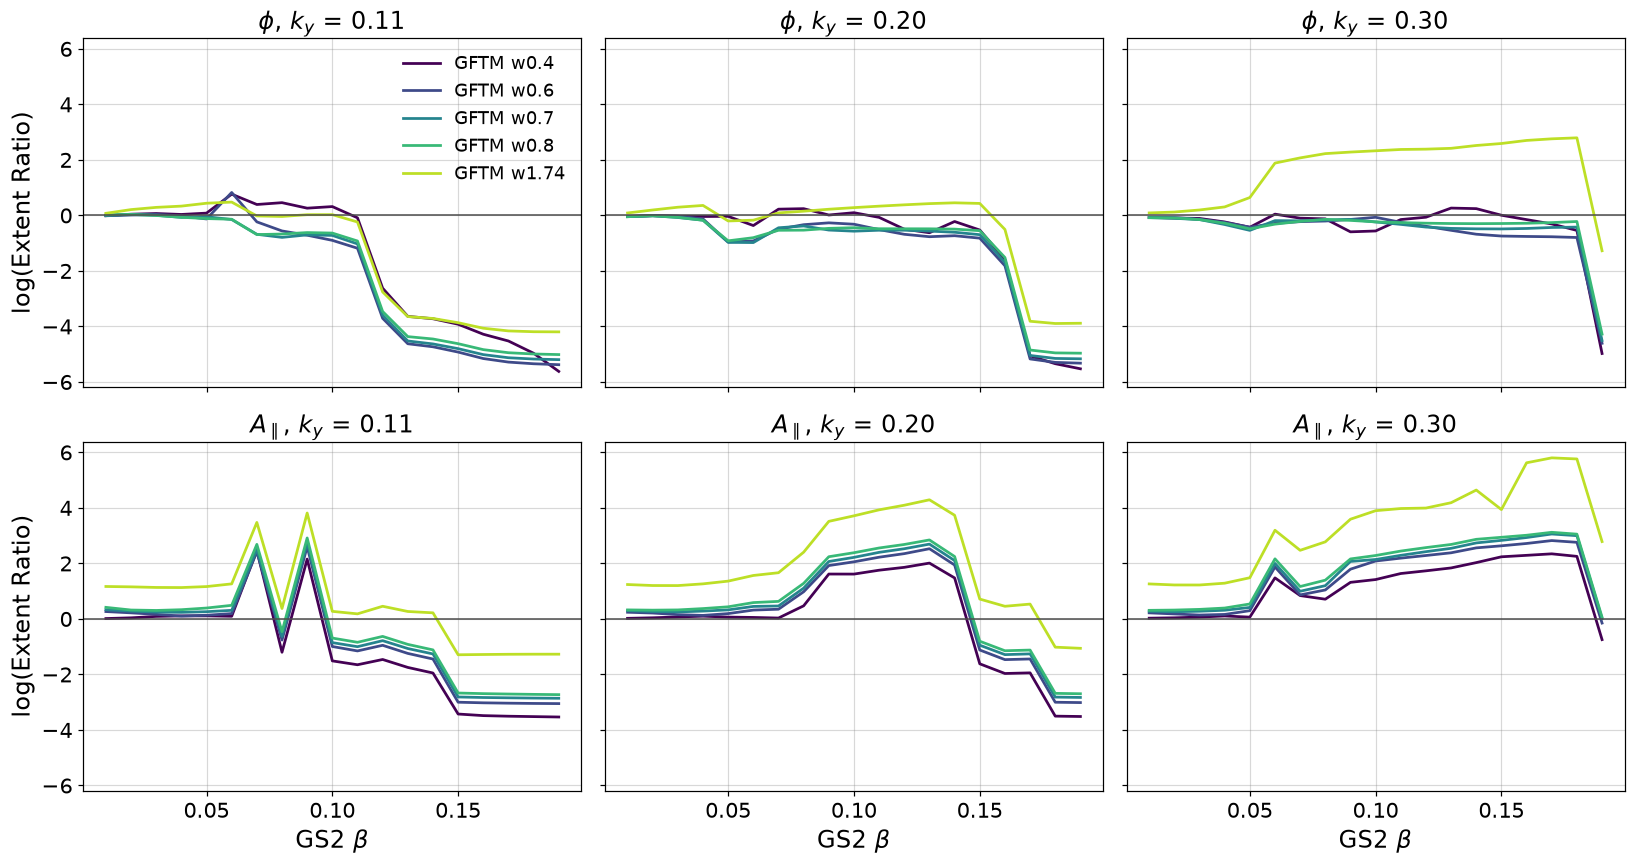

In [13]:
ext = {lab: {k: v(dominant(d, "extent").sel(field=k)) for k in ("phi", "apar")} for lab, d in R.items()}
box = float(np.ptp(v(R["GS2"].theta)))
unconv = tol >= tol_unconverged

fig_ext, axes = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True)
fig_rat, axes_r = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True, sharey=True)
for col, i in enumerate(iky):
    for row, k in enumerate(("phi", "apar")):
        ax, axr = axes[row, col], axes_r[row, col]
        e2 = ext["GS2"][k][i]
        ax.plot(beta_r4, e2, color="k", label="GS2", marker="none")
        ax.plot(beta_r4[~unconv[i]], e2[~unconv[i]], color="k", ls="", marker="o", ms=5)
        ax.plot(beta_r4[unconv[i]], e2[unconv[i]], color="k", ls="", marker="o", ms=5, mfc="none")
        for lab in r4_codes:
            ax.plot(beta_r4, ext[lab][k][i], color=colour[lab], label=lab, marker="none")
            axr.plot(beta_r4, np.log2(ext[lab][k][i] / e2), color=colour[lab], label=lab, marker="none")
        ax.axhline(box, color="0.5", ls=":", lw=1, marker="")
        axr.axhline(0, color="0.3", lw=1, marker="")
        ax.set_yscale("log")
        ax.set_title(rf"{field_label[k]}, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
        axr.set_title(rf"{field_label[k]}, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
for a in (axes, axes_r):
    for ax in a.flat:
        ax.tick_params(labelsize=14)
    for ax in a[-1]:
        ax.set_xlabel(r"GS2 $\beta$", fontsize=16)
for row, k in enumerate(("phi", "apar")):
    axes[row, 0].set_ylabel(f"{field_label[k]} extent [rad]", fontsize=16)
    axes_r[row, 0].set_ylabel("log(Extent Ratio)", fontsize=16)
axes[0, 0].legend(fontsize=12)
axes_r[0, 0].legend(fontsize=12)
fig_ext.tight_layout()
fig_rat.tight_layout()
plt.show()

### (3) γ, ω, T and mode type vs β

Dominant mode per code. GS2 indicators from each run (`mode_classification.indicators` + `classify`, full
criteria); code type from T and ω only (`code_type` above). Current cutoffs are printed. Markers where γ > 0:
▲ MTM, ■ KBM, ● mixed; GS2 open = unconverged (tol ≥ 0.1). TGLF default / V5 in grey for context (no markers).
GFTM WIDTH 1.74 has no stored `tearing_parameter`, so its T is computed with pyro's
`FieldLine.compute_linear_tearing_parameter` (the function that wrote the stored values for the other leaves) from
that leaf's stored A∥ eigenfunction (`eig_T`, checked against the stored T of every other leaf above).

cutoffs: T_BAL 0.05 T_TEAR 0.15 CHI_KBM (0.25, 4.0)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/.v

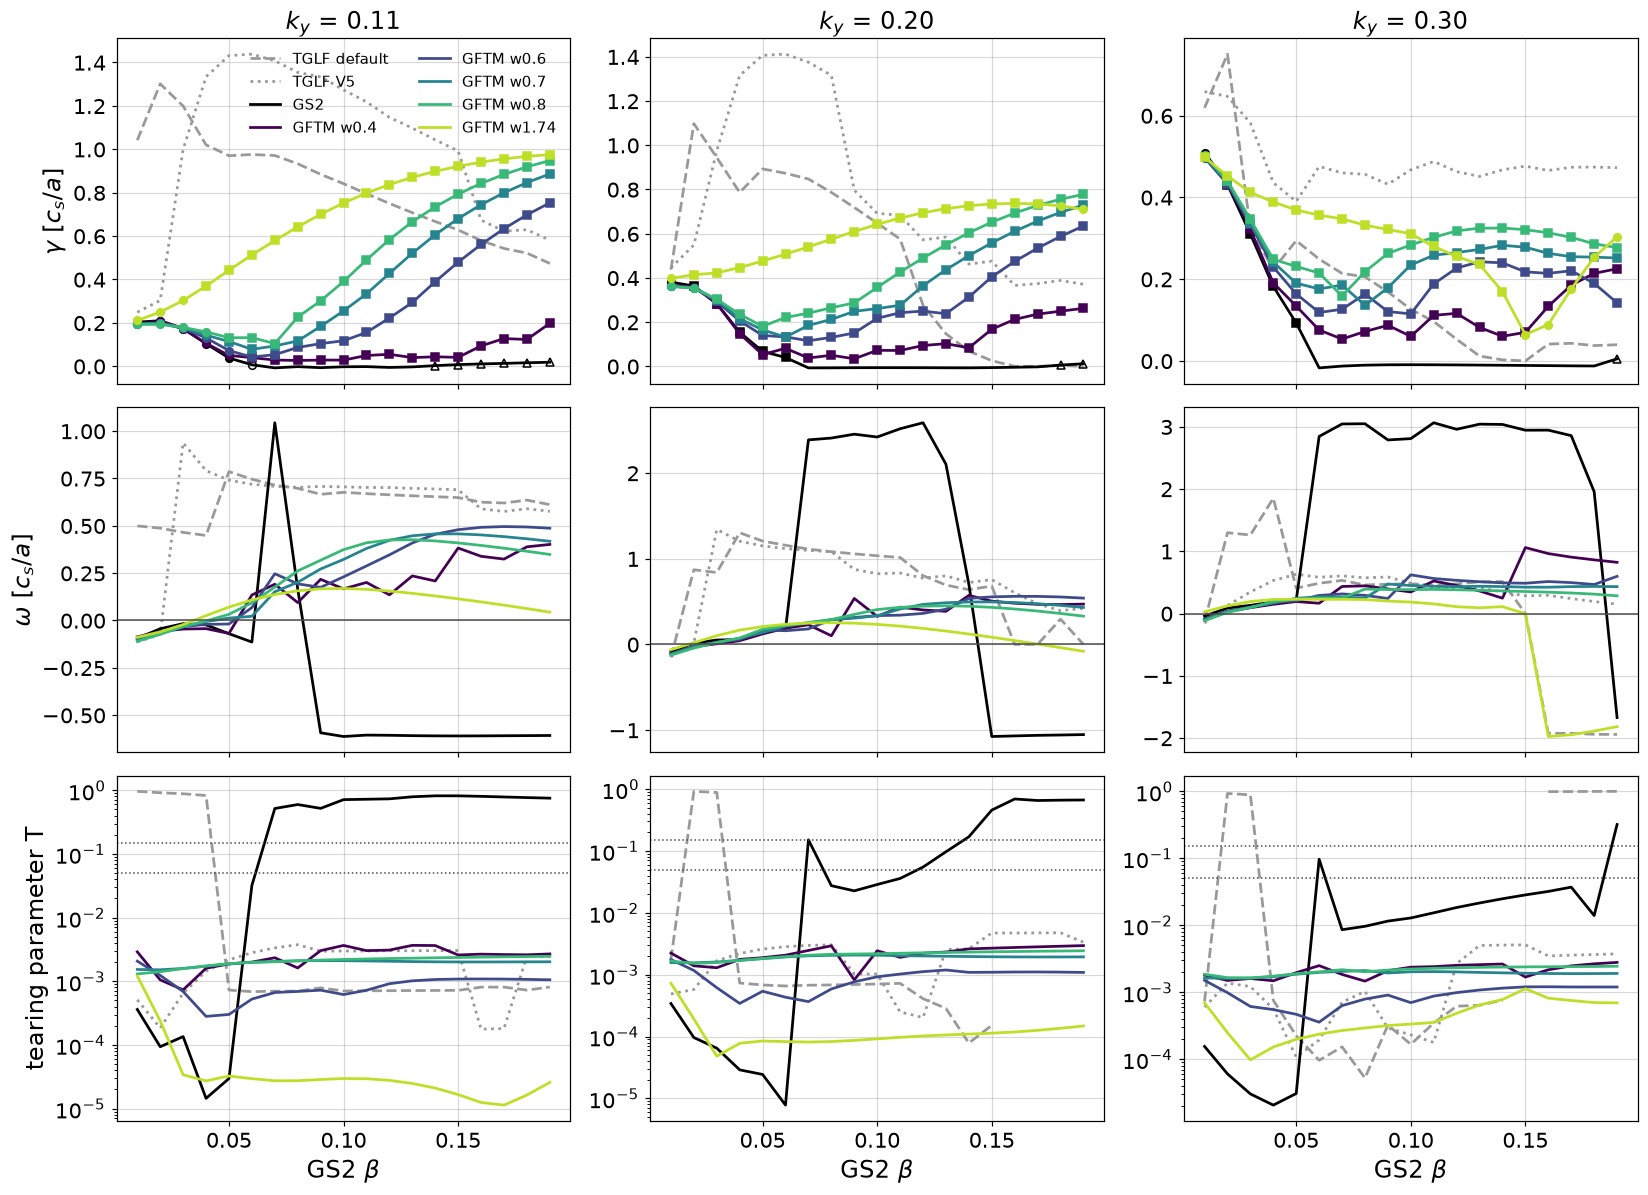

ky 0.112 GS2         m m m m m m - - - - - - - M M M M M M
ky 0.112 GFTM w0.4   m m m m m K K K K K K K K K K K K K K
ky 0.112 GFTM w0.6   m m m m m K K K K K K K K K K K K K K
ky 0.112 GFTM w0.7   m m m m K K K K K K K K K K K K K K K
ky 0.112 GFTM w0.8   m m m m K K K K K K K K K K K K K K K
ky 0.112 GFTM w1.74  m m m K K K K K K K K K K K K K K K K
ky 0.200 GS2         m K K K K K - - - - - - - - - - - M M
ky 0.200 GFTM w0.4   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w0.6   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w0.7   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w0.8   m m K K K K K K K K K K K K K K K K K
ky 0.200 GFTM w1.74  m K K K K K K K K K K K K K K K K m m
ky 0.300 GS2         m K K K K - - - - - - - - - - - - - M
ky 0.300 GFTM w0.4   m K K K K K K K K K K K K K K K K K K
ky 0.300 GFTM w0.6   m K K K K K K K K K K K K K K K K K K
ky 0.300 GFTM w0.7   m K K K K K K K K K K K K K K K K K K
ky 0.300 GFTM w0.8   m K K K K K K K K K K K K K K K K K

In [14]:
print("cutoffs: T_BAL", mc.T_BAL, "T_TEAR", mc.T_TEAR, "CHI_KBM", mc.CHI_KBM)


def gs2_run(i, j):
    return data_root / gs2_code / run_template / gs2_project / r4 / gs2_scan / f"ky{float(gs2[r4].ky[i]):.3f}_beta{beta_r4[j]:.3f}"


gs2_ind = {(i, j): gs2_indicators(r4, i, j) for i in iky for j in range(beta_r4.size)}
R["GFTM w1.74"]["tearing_parameter"] = (("ky", "beta", "mode"), eig_T(r4_pyroscan["GFTM w1.74"]))

w = {lab: v(dominant(d, "mode_frequency")) for lab, d in R.items()}
T = {lab: v(dominant(d, "tearing_parameter")) for lab, d in R.items() if lab != "GS2"}
T["GS2"] = np.full(g["GS2"].shape, np.nan)
for (i, j), ind in gs2_ind.items():
    T["GS2"][i, j] = ind["T"]
label = {lab: code_type(T[lab], w[lab]) for lab in r4_codes}
label["GS2"] = {k: mc.classify(ind) for k, ind in gs2_ind.items()}
tglf = {lab: model[(r4, lab)] for lab in ("TGLF default", "TGLF V5")}
tglf_dom = {lab: ds.growth_rate.fillna(-np.inf).argmax("mode") for lab, ds in tglf.items()}

fig_gwt, axes = plt.subplots(3, len(iky), figsize=(5 * len(iky), 11), sharex=True)
for col, i in enumerate(iky):
    for lab, ls in zip(tglf, ("--", ":")):
        ds, m = tglf[lab], tglf_dom[lab]
        for row, var in enumerate(("growth_rate", "mode_frequency", "tearing_parameter")):
            axes[row, col].plot(beta_r4, ds[var].isel(mode=m).values[i], color="0.6", ls=ls, label=lab, marker="none")
    for lab in ["GS2", *r4_codes]:
        c = line_colour[lab]
        for row, y in enumerate((g[lab][i], w[lab][i], T[lab][i])):
            axes[row, col].plot(beta_r4, y, color=c, label=lab, marker="none")
        for j in range(beta_r4.size):
            if g[lab][i, j] > gamma_floor:
                t = label[lab][i, j]
                open_ = lab == "GS2" and unconv[i, j]
                axes[0, col].plot(beta_r4[j], g[lab][i, j], color=c, ls="", marker=marker[t], ms=5, mfc="none" if open_ else c)
    axes[0, col].set_title(rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
    axes[2, col].set_yscale("log")
    axes[2, col].axhline(mc.T_BAL, color="0.3", ls=":", lw=1, marker="")
    axes[2, col].axhline(mc.T_TEAR, color="0.3", ls=":", lw=1, marker="")
    axes[1, col].axhline(0, color="0.3", lw=1, marker="")
for row, yl in enumerate((r"$\gamma$ [$c_s/a$]", r"$\omega$ [$c_s/a$]", "tearing parameter T")):
    axes[row, 0].set_ylabel(yl, fontsize=16)
for ax in axes.flat:
    ax.tick_params(labelsize=14)
for ax in axes[-1]:
    ax.set_xlabel(r"GS2 $\beta$", fontsize=16)
axes[0, 0].legend(fontsize=10, ncol=2)
fig_gwt.tight_layout()
plt.show()

for i in iky:
    for lab in ["GS2", *r4_codes]:
        print(f"ky {float(gs2[r4].ky[i]):.3f} {lab:11s}", " ".join(
            f"{label[lab][i, j][0] if g[lab][i, j] > 0 else '-'}" for j in range(beta_r4.size)))

### (4) GS2 trust: convergence per cell and γ(t) at the eigenfunction cells

`growth_rate_tolerance` per plotted cell (tol < 1e-2 converged, ≥ 1e-1 unconverged), then GS2's own γ(t) at the three
eigenfunction cells, with the GFTM γ at the same cell as horizontal lines. A mode growing at γ for the GS2 run time
t_end would have grown by exp(γ t_end); that number is printed.

        0.11    0.2     0.3 
0.01 6.7e-05 5.3e-05 7.9e-06
0.02 3.6e-05 5.9e-05 1.4e-05
0.03  0.0018 0.00028 3.9e-05
0.04 0.00041 0.00027 8.6e-05
0.05 0.00092  0.0031 0.00034
0.06     2.4  0.0005     1.2
0.07     1.1     1.1    0.21
0.08     1.1    0.73    0.25
0.09     1.1    0.64    0.19
0.1      1.9    0.57    0.06
0.11     1.1    0.57   0.053
0.12     1.2    0.67   0.018
0.13     1.1    0.82   0.034
0.14     1.2    0.83   0.016
0.15     1.6     1.1   0.017
0.16     1.9     1.1   0.015
0.17     3.1     1.1   0.022
0.18     2.5     1.8   1e+02
0.19     0.3    0.73     1.5
ky 0.112 beta>=0.07: converged 0, marginal 0, unconverged 13 of 13; max |gamma_GS2| 0.018
ky 0.200 beta>=0.07: converged 0, marginal 0, unconverged 13 of 13; max |gamma_GS2| 0.012
ky 0.300 beta>=0.07: converged 0, marginal 8, unconverged 5 of 13; max |gamma_GS2| 0.013


control: GFTM w0.4 gamma 0.360, t_end 24, gamma*t_end 9
control: GFTM w0.8 gamma 0.354, t_end 24, gamma*t_end 9
control: GFTM w1.74 gamma 0.414, t_end 24, gamma*t_end 10
high, ky 0.11: GFTM w0.4 gamma 0.041, t_end 341, gamma*t_end 14
high, ky 0.11: GFTM w0.8 gamma 0.793, t_end 341, gamma*t_end 271
high, ky 0.11: GFTM w1.74 gamma 0.921, t_end 341, gamma*t_end 314
high, ky 0.2: GFTM w0.4 gamma 0.168, t_end 341, gamma*t_end 57
high, ky 0.2: GFTM w0.8 gamma 0.652, t_end 341, gamma*t_end 222
high, ky 0.2: GFTM w1.74 gamma 0.734, t_end 341, gamma*t_end 251


/scratch_local/ipykernel_1995052/3577424000.py:26: UserWarning: The figure layout has changed to tight
  fig_gt.tight_layout()


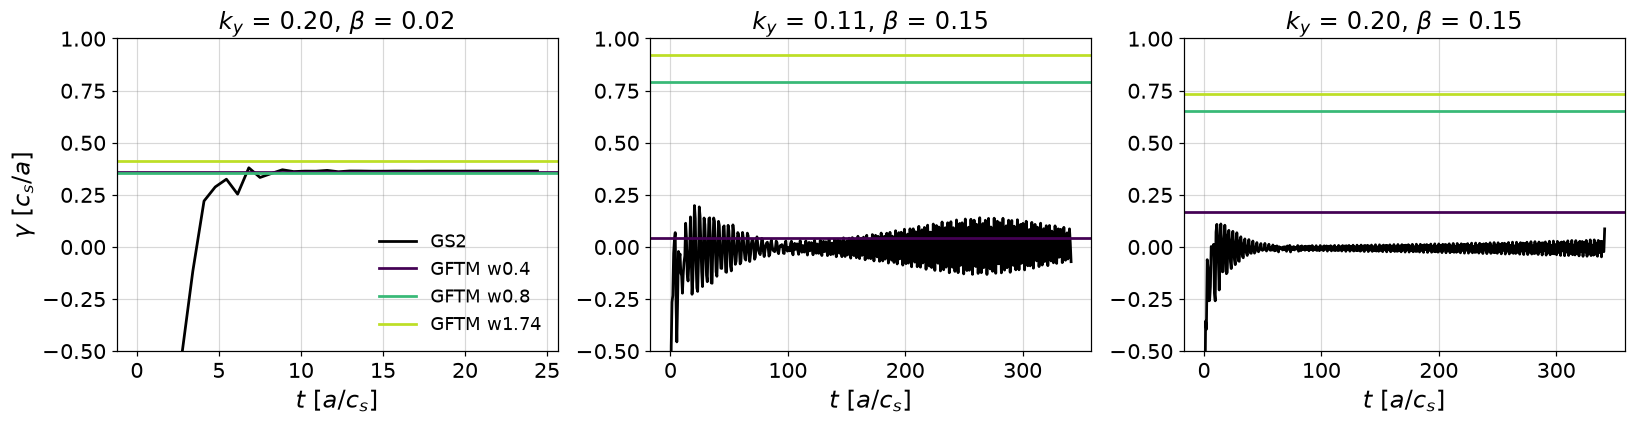

In [15]:
tol_table = pd.DataFrame(tol[iky].T, index=beta_r4.round(2), columns=[round(float(gs2[r4].ky[i]), 3) for i in iky])
with pd.option_context("display.float_format", "{:.2g}".format):
    print(tol_table)
for i in iky:
    hi = beta_r4 >= 0.07
    print(f"ky {float(gs2[r4].ky[i]):.3f} beta>=0.07: converged {(tol[i, hi] < 1e-2).sum()}, marginal "
          f"{((tol[i, hi] >= 1e-2) & (tol[i, hi] < 1e-1)).sum()}, unconverged {(tol[i, hi] >= 1e-1).sum()} of {hi.sum()}; "
          f"max |gamma_GS2| {np.abs(g['GS2'][i, hi]).max():.3f}")

fig_gt, axes = plt.subplots(1, len(cells), figsize=(5 * len(cells), 4))
for ax, (name, (i, j)) in zip(axes, cells.items()):
    pyro = Pyro(gk_file=gs2_run(i, j) / "gs2.in")
    pyro.load_gk_output(load_fields=True, load_fluxes=False)
    gt = pyro.gk_output["growth_rate"].squeeze()
    t = v(gt.time)
    ax.plot(t, v(gt), color="k", label="GS2", marker="none")
    for lab in ("GFTM w0.4", "GFTM w0.8", "GFTM w1.74"):
        ax.axhline(g[lab][i, j], color=colour[lab], label=lab, marker="")
        print(f"{name}: {lab} gamma {g[lab][i, j]:.3f}, t_end {t[-1]:.0f}, gamma*t_end {g[lab][i, j] * t[-1]:.0f}")
    ax.set_title(rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}, $\beta$ = {beta_r4[j]:.2f}", fontsize=16)
    ax.set_xlabel(r"$t$ [$a/c_s$]", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.set_ylim(-0.5, 1.0)
axes[0].set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
axes[0].legend(fontsize=12)
fig_gt.tight_layout()
plt.show()

### (5) WIDTH dependence at fixed high β

Dominant GFTM γ and log(Extent Ratio) of φ against WIDTH at β = 0.15 (GS2 number), one line per ky; GS2's γ at the
same cell dotted in the same colour.

/scratch_local/ipykernel_1995052/2422550590.py:23: UserWarning: The figure layout has changed to tight
  fig_w.tight_layout()


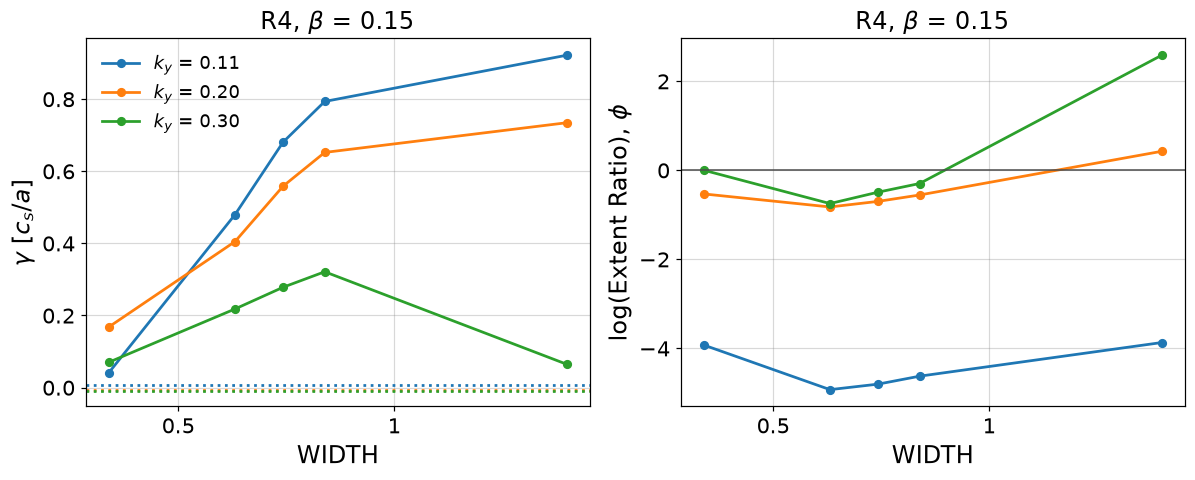

ky 0.112 beta 0.15: GS2 gamma +0.007 | W0.4 +0.041  W0.6 +0.480  W0.7 +0.680  W0.8 +0.793  W1.74 +0.921
ky 0.200 beta 0.15: GS2 gamma -0.006 | W0.4 +0.168  W0.6 +0.405  W0.7 +0.558  W0.8 +0.652  W1.74 +0.734
ky 0.300 beta 0.15: GS2 gamma -0.011 | W0.4 +0.070  W0.6 +0.218  W0.7 +0.278  W0.8 +0.321  W1.74 +0.064


In [16]:
widths = np.array([spec[3] for spec in r4_codes.values()])
fig_w, (ax_g, ax_e) = plt.subplots(1, 2, figsize=(11, 4.5))
for c, i in enumerate(iky):
    ky_lab = rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}"
    ax_g.plot(widths, [g[lab][i, jhi] for lab in r4_codes], color=f"C{c}", marker="o", ms=5, label=ky_lab)
    ax_g.axhline(g["GS2"][i, jhi], color=f"C{c}", ls=":", marker="")
    ax_e.plot(widths, [np.log2(ext[lab]["phi"][i, jhi] / ext["GS2"]["phi"][i, jhi]) for lab in r4_codes],
              color=f"C{c}", marker="o", ms=5, label=ky_lab)
ax_e.axhline(0, color="0.3", lw=1, marker="")
ax_g.set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
ax_e.set_ylabel(r"log(Extent Ratio), $\phi$", fontsize=16)
for ax in (ax_g, ax_e):
    ax.set_xscale("log")
    lims = ax.get_xlim()
    ax.set_xticks([0.5, 1, 2, 5, 10])
    ax.set_xlim(lims)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.minorticks_off()
    ax.set_xlabel("WIDTH", fontsize=16)
    ax.set_title(rf"R4, $\beta$ = {beta_r4[jhi]:.2f}", fontsize=16)
    ax.tick_params(labelsize=14)
ax_g.legend(fontsize=12)
fig_w.tight_layout()
plt.show()
for i in iky:
    print(f"ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[jhi]:.2f}: GS2 gamma {g['GS2'][i, jhi]:+.3f} | " +
          "  ".join(f"W{wd:g} {g[lab][i, jhi]:+.3f}" for wd, lab in zip(widths, r4_codes)))

### β′ and field consistency at the high-β cell

Same cell read by both codes' own decks through pyro, in pyrokinetics normalisation: β, β′, q, ŝ and the field
switches. If these differ, GFTM is not being asked the same question as GS2.

In [17]:
i, j = cells["high, ky 0.2"]
code, project, leaf, _ = r4_codes["GFTM w1.74"]
decks = {"GS2": gs2_run(i, j) / "gs2.in",
         "GFTM w1.74": data_root / code / run_template / project / r4 / leaf / f"ky{float(gs2[r4].ky[i]):.3f}_beta{beta_r4[j]:.3f}" / "input.gftm"}
for lab, path in decks.items():
    p = Pyro(gk_file=path)
    lg, nu = p.local_geometry, p.numerics
    print(f"{lab:10s} beta {nu.beta.to(p.norms.pyrokinetics).m:.6f}  beta' {lg.beta_prime.to(p.norms.pyrokinetics).m:.6f}  "
          f"q {lg.q.m:.4f}  shat {lg.shat.m:.4f}  phi {nu.phi} apar {nu.apar} bpar {nu.bpar}")

r4_figs = {"R4_eigenfunctions": fig_eig, "R4_eigenfunction_phase": fig_ph, "R4_extent_vs_beta": fig_ext,
           "R4_extent_ratio_vs_beta": fig_rat, "R4_gamma_omega_T_vs_beta": fig_gwt, "R4_gs2_gamma_t": fig_gt,
           "R4_gamma_extent_vs_width": fig_w}
for name, fig in r4_figs.items():
    fig.savefig(output_dir / f"{name}.png", dpi=150, bbox_inches="tight")
print("saved", len(r4_figs), "R4 figures to", output_dir)

GS2        beta 0.131640  beta' -2.055328  q 5.3076  shat 1.9661  phi True apar True bpar True
GFTM w1.74 beta 0.131640  beta' -2.055328  q 5.3076  shat 1.9661  phi True apar True bpar True


saved 7 R4 figures to /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e94/Plots/beta_stabilisation_f05


### (6.1) Ideal-ballooning stability of R4 vs β (follow-up 1, approved by the user 2026-10-02)

pyro `Diagnostics.ideal_ballooning_solver` at θ0 = 0, on GS2's own R4 decks (one per β; ideal MHD is ky-independent,
so the ky 0.2 decks are used), at each deck's own numerics and at nperiod 5 / ntheta 64 (the setting earlier s-α
work used). Only the **sign** of γ_ideal is meaningful: for a stable case |γ| shrinks as the ballooning domain grows.
x axis α = q² (R/a) |β′| with β′ in pyrokinetics normalisation.

**Positive control:** the M1_A1 GS2 template (`$GYRO_DATA_INPUT/GS2/Templates/M1_A1`), where Fusion_PhD-52l found
an ideal-unstable band α ≈ 4.4–11.8, with β′ scaled to each α (geometry otherwise fixed), and R4's β = 0.15 deck
scaled the same way to extend its α range down to 0.5.

R4 alpha over the GS2 beta grid: [  7.3  14.7  22.   29.3  36.6  44.   51.3  58.6  66.   73.3  80.6  87.9
  95.3 102.6 109.9 117.2 124.6 131.9 139.2]
R4 decks, deck: unstable (gamma_ideal > 0) in 0 of 19
R4 decks, nperiod 5, ntheta 64: unstable (gamma_ideal > 0) in 0 of 19
M1_A1 (control): unstable alpha [ 5.  6.  8. 10.]
R4, β′ scaled: unstable alpha []


/scratch_local/ipykernel_1995052/868840457.py:54: UserWarning: The figure layout has changed to tight
  fig_ib.tight_layout()


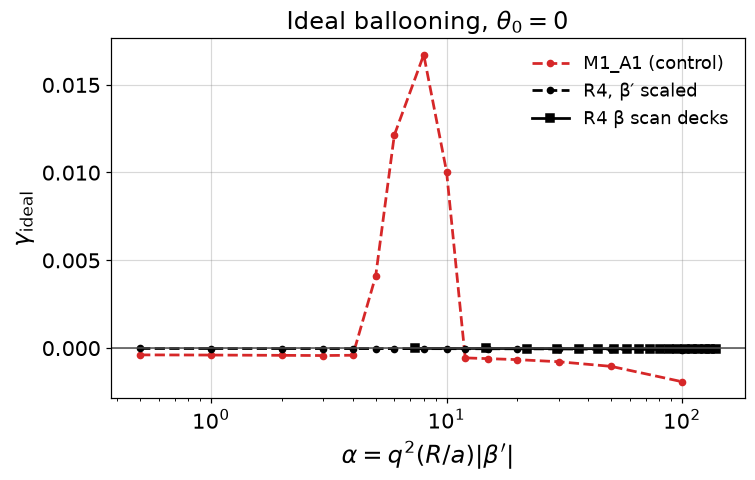

In [18]:
from pyrokinetics.diagnostics import Diagnostics


def alpha_of(p):
    lg = p.local_geometry
    return float(lg.q.m ** 2 * lg.Rmaj.m * abs(lg.beta_prime.to(p.norms.pyrokinetics).m))


def ideal(p, nperiod=None, ntheta=None):
    if nperiod:
        p.numerics.nperiod, p.numerics.ntheta = nperiod, ntheta
    return float(Diagnostics(p).ideal_ballooning_solver(theta0=0.0))


ideal_numerics = {"deck": (None, None), "nperiod 5, ntheta 64": (5, 64)}
alpha_r4, g_ideal_r4 = np.zeros(beta_r4.size), {k: np.zeros(beta_r4.size) for k in ideal_numerics}
for j in range(beta_r4.size):
    for k, (nper, nth) in ideal_numerics.items():
        p = Pyro(gk_file=gs2_run(iky[1], j) / "gs2.in")
        alpha_r4[j] = alpha_of(p)
        g_ideal_r4[k][j] = ideal(p, nper, nth)

alpha_scan = np.array([0.5, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30, 50, 100])
control = {"M1_A1 (control)": Path(os.environ["GYRO_DATA_INPUT"]) / "GS2/Templates/M1_A1/gs2.in",
           "R4, β′ scaled": gs2_run(iky[1], jhi) / "gs2.in"}
g_scan = {}
for name, deck in control.items():
    p = Pyro(gk_file=deck, gk_code="GS2")
    bp0, a0 = p.local_geometry.beta_prime, alpha_of(p)
    p.numerics.nperiod, p.numerics.ntheta = 5, 64
    g_scan[name] = []
    for a in alpha_scan:
        p.local_geometry.beta_prime = bp0 * (a / a0)
        g_scan[name].append(ideal(p))

print("R4 alpha over the GS2 beta grid:", alpha_r4.round(1))
for k, gi in g_ideal_r4.items():
    print(f"R4 decks, {k}: unstable (gamma_ideal > 0) in {(gi > 0).sum()} of {gi.size}")
for name, gi in g_scan.items():
    gi = np.array(gi)
    print(f"{name}: unstable alpha", alpha_scan[gi > 0])

fig_ib, ax = plt.subplots(figsize=(7, 4.5))
for (name, gi), c in zip(g_scan.items(), ("C3", "k")):
    ax.plot(alpha_scan, gi, color=c, ls="--", marker="o", ms=4, label=name)
ax.plot(alpha_r4, g_ideal_r4["deck"], color="k", marker="s", ms=5, label="R4 β scan decks")
ax.axhline(0, color="0.3", lw=1, marker="")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha = q^2 (R/a) |\beta'|$", fontsize=16)
ax.set_ylabel(r"$\gamma_{\rm ideal}$", fontsize=16)
ax.set_title(r"Ideal ballooning, $\theta_0 = 0$", fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=12)
fig_ib.tight_layout()
plt.show()
fig_ib.savefig(output_dir / "R4_ideal_ballooning.png", dpi=150, bbox_inches="tight")

### A∥ vs β per WIDTH (user request 2026-10-02)

Dominant mode. Top: pyro `Extent` of A∥ (95% of ∫|A∥|²dθ). Bottom: peak |A∥| / peak |φ| of the same eigenfunction,
both codes in pyro's normalisation. GS2 open = unconverged (tol ≥ 0.1).

/scratch_local/ipykernel_1995052/4157849195.py:3: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.abs(v(e.sel(field="apar"))), axis=-1) / np.nanmax(np.abs(v(e.sel(field="phi"))), axis=-1)
/scratch_local/ipykernel_1995052/4157849195.py:24: UserWarning: The figure layout has changed to tight
  fig_apar.tight_layout()


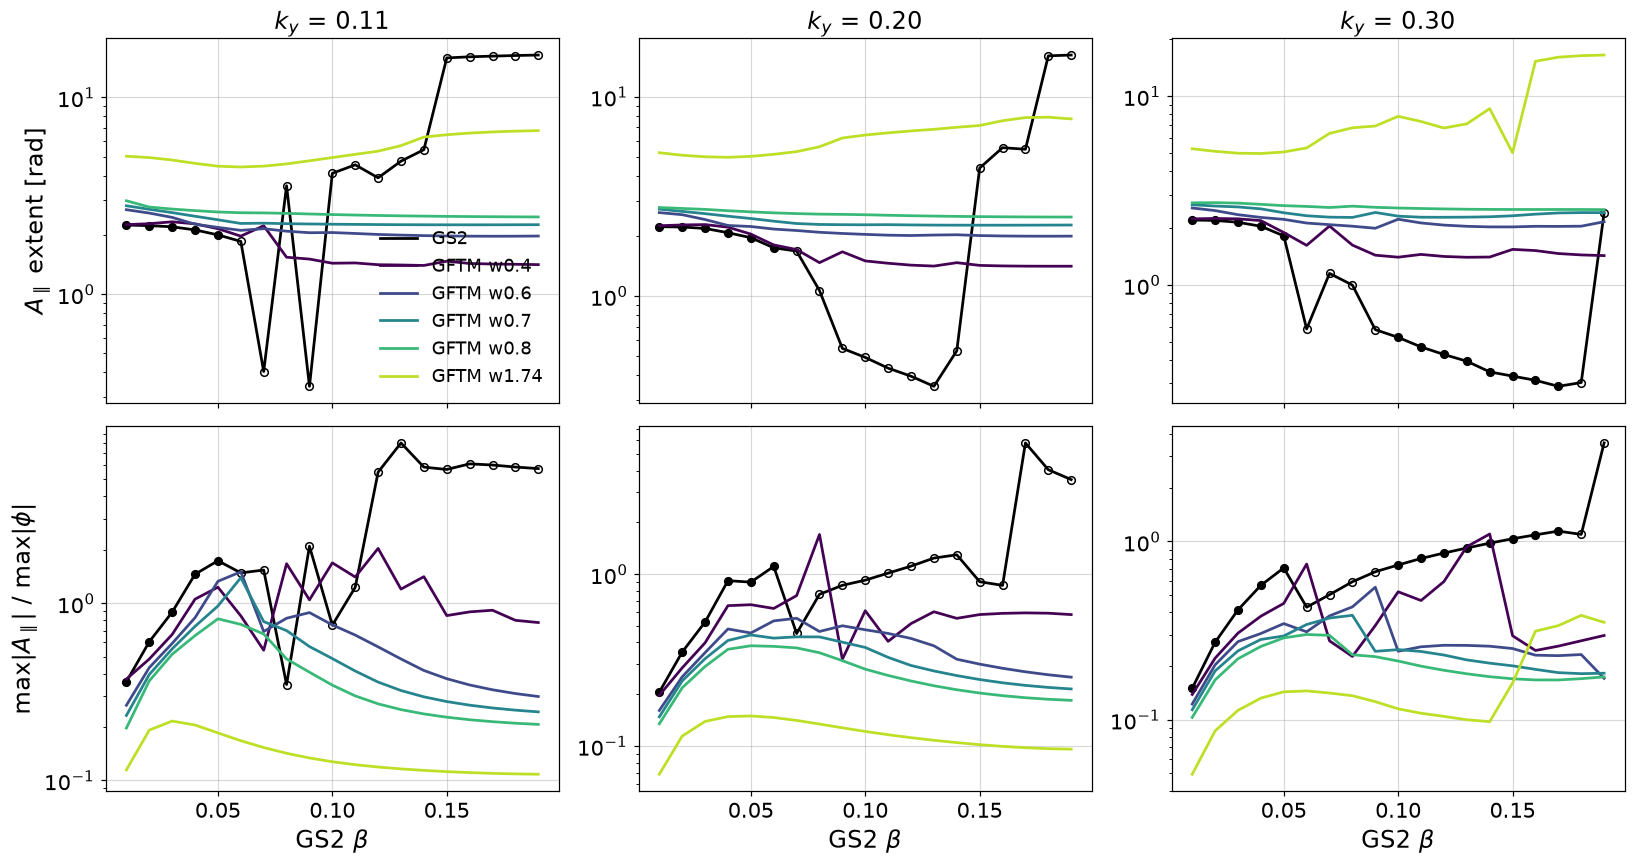

ky 0.112 beta 0.02  Apar extent / ratio: GS2 2.23/0.61  w0.4 2.28/0.48  w0.6 2.58/0.43  w0.7 2.70/0.40  w0.8 2.77/0.36  w1.74 4.94/0.19
ky 0.112 beta 0.15  Apar extent / ratio: GS2 15.86/5.68  w0.4 1.47/0.85  w0.6 1.97/0.37  w0.7 2.25/0.28  w0.8 2.48/0.23  w1.74 6.45/0.11
ky 0.200 beta 0.02  Apar extent / ratio: GS2 2.21/0.35  w0.4 2.27/0.28  w0.6 2.55/0.25  w0.7 2.65/0.24  w0.8 2.74/0.22  w1.74 5.08/0.11
ky 0.200 beta 0.15  Apar extent / ratio: GS2 4.38/0.90  w0.4 1.42/0.58  w0.6 2.01/0.30  w0.7 2.26/0.24  w0.8 2.50/0.20  w1.74 7.16/0.10
ky 0.300 beta 0.02  Apar extent / ratio: GS2 2.19/0.27  w0.4 2.25/0.22  w0.6 2.47/0.20  w0.7 2.61/0.19  w0.8 2.72/0.17  w1.74 5.10/0.09
ky 0.300 beta 0.15  Apar extent / ratio: GS2 0.33/1.03  w0.4 1.54/0.30  w0.6 2.03/0.25  w0.7 2.32/0.20  w0.8 2.51/0.17  w1.74 5.01/0.16


In [19]:
def apar_ratio(d):
    e = dominant(d, "eigenfunctions")
    return np.nanmax(np.abs(v(e.sel(field="apar"))), axis=-1) / np.nanmax(np.abs(v(e.sel(field="phi"))), axis=-1)


ratio = {lab: apar_ratio(d) for lab, d in R.items()}
fig_apar, axes = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True)
for col, i in enumerate(iky):
    for row, y in enumerate((ext, ratio)):
        ax = axes[row, col]
        yy = {lab: (y[lab]["apar"] if row == 0 else y[lab])[i] for lab in R}
        ax.plot(beta_r4, yy["GS2"], color="k", label="GS2", marker="none")
        ax.plot(beta_r4[~unconv[i]], yy["GS2"][~unconv[i]], color="k", ls="", marker="o", ms=5)
        ax.plot(beta_r4[unconv[i]], yy["GS2"][unconv[i]], color="k", ls="", marker="o", ms=5, mfc="none")
        for lab in r4_codes:
            ax.plot(beta_r4, yy[lab], color=colour[lab], label=lab, marker="none")
        ax.set_yscale("log")
        ax.tick_params(labelsize=14)
    axes[0, col].set_title(rf"$k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
    axes[1, col].set_xlabel(r"GS2 $\beta$", fontsize=16)
axes[0, 0].set_ylabel(r"$A_\parallel$ extent [rad]", fontsize=16)
axes[1, 0].set_ylabel(r"max$|A_\parallel|$ / max$|\phi|$", fontsize=16)
axes[0, 0].legend(fontsize=12)
fig_apar.tight_layout()
plt.show()
fig_apar.savefig(output_dir / "R4_apar_vs_beta.png", dpi=150, bbox_inches="tight")
for i in iky:
    for j in (jlo, jhi):
        print(f"ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[j]:.2f}  Apar extent / ratio: " + "  ".join(
            f"{lab.replace('GFTM ', '')} {ext[lab]['apar'][i, j]:.2f}/{ratio[lab][i, j]:.2f}" for lab in R))

### (7) GFTM convergence study (follow-ups 2-4, user go-ahead 2026-10-05)
Leaves under `GFTM/Runs/scan_beta_f05_conv/R4/` (Fusion_PhD `results/r4_gftm_convergence/config.yaml`), each the
`scan_beta_f05/R4/w0p8` deck with one setting changed, at the three plotted ky: `width_0p2/0p25/0p3/0p5` (WIDTH, 19 β),
`nb<NBASIS_MAX>_nx<NXGRID>_w0p8/w1p74` (4 β: the β 0.02 control and β 0.10/0.15/0.19), and `nobpar_w0p4/0p8/1p74`
(`numerics.bpar = False`, i.e. `USE_BPAR = F`, 19 β). Dominant mode = argmax γ. β is GS2's number throughout.

/scratch_local/ipykernel_1995052/3216528222.py:33: UserWarning: The figure layout has changed to tight
  fig_ws.tight_layout()


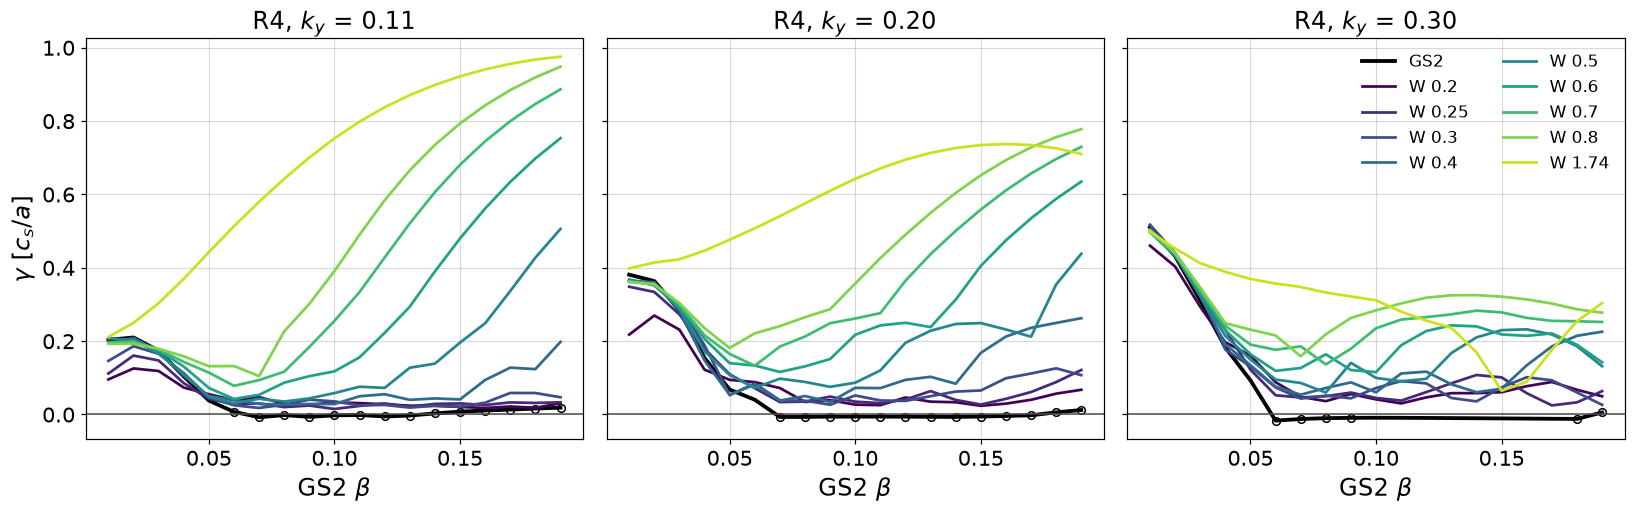

ky 0.112: max gamma at beta>=0.07 (GS2 +0.018) | W0.2 0.047  W0.25 0.033  W0.3 0.058  W0.4 0.198  W0.5 0.506  W0.6 0.753  W0.7 0.886  W0.8 0.948  W1.74 0.975
ky 0.200: max gamma at beta>=0.07 (GS2 +0.012) | W0.2 0.072  W0.25 0.121  W0.3 0.125  W0.4 0.262  W0.5 0.438  W0.6 0.635  W0.7 0.729  W0.8 0.778  W1.74 0.737
ky 0.300: max gamma at beta>=0.07 (GS2 +0.005) | W0.2 0.088  W0.25 0.107  W0.3 0.101  W0.4 0.225  W0.5 0.232  W0.6 0.243  W0.7 0.283  W0.8 0.325  W1.74 0.347


In [20]:
def load_conv(leaf):
    d = load_r4("GFTM", "scan_beta_f05_conv", leaf).gk_output.data
    return d.squeeze("bpar", drop=True) if "bpar" in d.dims else d


C = {leaf: load_conv(leaf) for leaf in
     ["width_0p2", "width_0p25", "width_0p3", "width_0p5", "nobpar_w0p4", "nobpar_w0p8", "nobpar_w1p74",
      *(f"nb{nb}_nx{nx}_w{w}" for w in ("0p8", "1p74") for nb, nx in ((12, 32), (16, 32), (20, 32), (12, 48), (12, 64), (20, 64)))]}
jconv = [1, 9, 14, 18]   # beta indices of the nb*_nx* leaves: GS2 beta 0.02, 0.10, 0.15, 0.19
for leaf, d in C.items():
    assert np.allclose(v(d.ky), v(R["GS2"].ky)[iky], atol=1e-3), leaf
    assert d.beta.size == (4 if leaf.startswith("nb") else beta_r4.size), leaf
gc = {leaf: v(dominant(d, "growth_rate")) for leaf, d in C.items()}
gk = {w: gc[f"width_{str(w).replace('.', 'p')}"] for w in (0.2, 0.25, 0.3, 0.5)}
gk |= {spec[3]: g[lab][iky] for lab, spec in r4_codes.items()}
gk = dict(sorted(gk.items()))
wcol = {w: plt.cm.viridis(x) for w, x in zip(gk, np.linspace(0, 0.92, len(gk)))}
gs2_hi = beta_r4 >= 0.07

fig_ws, axes = plt.subplots(1, len(iky), figsize=(5 * len(iky), 4.8), sharey=True)
for col, i in enumerate(iky):
    ax = axes[col]
    ax.plot(beta_r4, g["GS2"][i], color="k", lw=2.5, label="GS2", marker="none")
    ax.plot(beta_r4[unconv[i]], g["GS2"][i, unconv[i]], color="k", ls="", marker="o", ms=5, mfc="none")
    for w, y in gk.items():
        ax.plot(beta_r4, y[col], color=wcol[w], label=f"W {w:g}", marker="none")
    ax.axhline(0, color="0.3", lw=1, marker="")
    ax.set_title(rf"R4, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
    ax.set_xlabel(r"GS2 $\beta$", fontsize=16)
    ax.tick_params(labelsize=14)
axes[0].set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
axes[-1].legend(fontsize=11, ncol=2)
fig_ws.tight_layout()
plt.show()
for col, i in enumerate(iky):
    print(f"ky {float(gs2[r4].ky[i]):.3f}: max gamma at beta>=0.07 (GS2 {g['GS2'][i, gs2_hi].max():+.3f}) | " +
          "  ".join(f"W{w:g} {y[col, gs2_hi].max():.3f}" for w, y in gk.items()))

/scratch_local/ipykernel_1995052/4066944058.py:18: UserWarning: The figure layout has changed to tight
  fig_res.tight_layout()


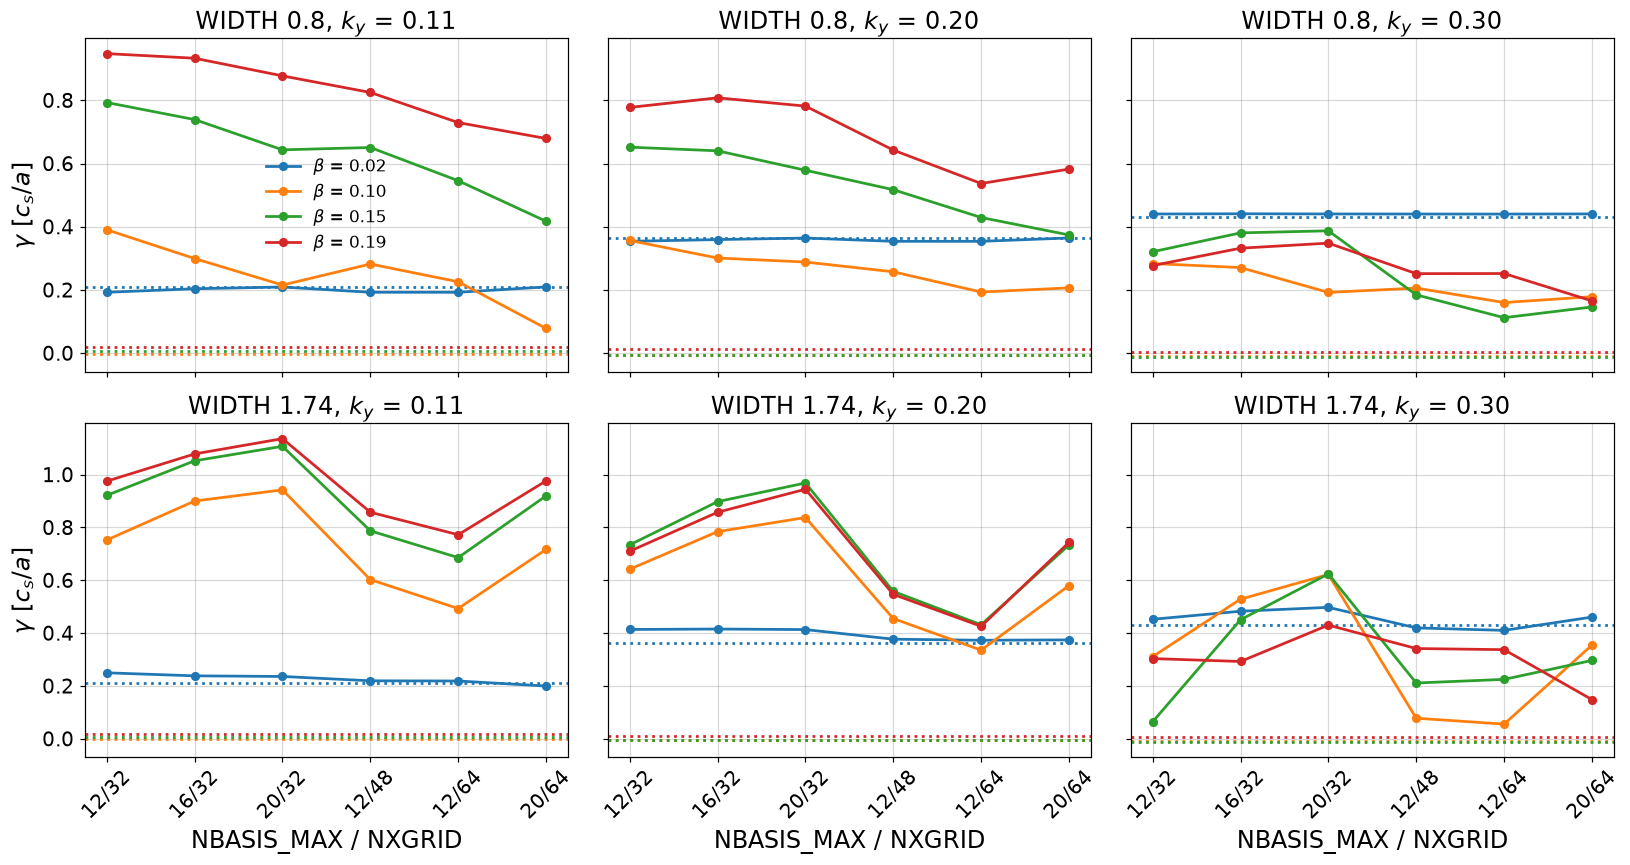

W0p8: max |gamma - gamma(12/32)| over settings, per ky x beta [0.02 0.1  0.15 0.19]:
 [[0.017 0.312 0.376 0.269]
 [0.011 0.163 0.278 0.241]
 [0.001 0.123 0.209 0.112]]
  ky 0.112: 12/32 0.193/0.391/0.793/0.948  16/32 0.204/0.299/0.739/0.933  20/32 0.209/0.216/0.643/0.877  12/48 0.193/0.282/0.651/0.825  12/64 0.193/0.226/0.546/0.730  20/64 0.210/0.078/0.417/0.679
  ky 0.200: 12/32 0.354/0.357/0.652/0.778  16/32 0.359/0.301/0.640/0.808  20/32 0.364/0.288/0.579/0.782  12/48 0.354/0.257/0.517/0.643  12/64 0.354/0.193/0.429/0.537  20/64 0.365/0.207/0.374/0.582
  ky 0.300: 12/32 0.440/0.284/0.321/0.277  16/32 0.441/0.271/0.381/0.332  20/32 0.441/0.192/0.387/0.348  12/48 0.440/0.206/0.185/0.252  12/64 0.440/0.160/0.112/0.252  20/64 0.441/0.179/0.146/0.165
W1p74: max |gamma - gamma(12/32)| over settings, per ky x beta [0.02 0.1  0.15 0.19]:
 [[0.05  0.259 0.236 0.203]
 [0.041 0.306 0.302 0.284]
 [0.045 0.311 0.56  0.155]]
  ky 0.112: 12/32 0.250/0.752/0.921/0.975  16/32 0.238/0.900/1.052/1.078

In [21]:
res = [(12, 32), (16, 32), (20, 32), (12, 48), (12, 64), (20, 64)]
fig_res, axes = plt.subplots(2, len(iky), figsize=(5 * len(iky), 8), sharex=True, sharey="row")
for row, w in enumerate(("0p8", "1p74")):
    for col, i in enumerate(iky):
        ax = axes[row, col]
        for b, (k, j) in enumerate(zip(range(4), jconv)):
            y = [gc[f"nb{nb}_nx{nx}_w{w}"][col, k] for nb, nx in res]
            ax.plot(range(len(res)), y, color=f"C{b}", marker="o", ms=5, label=rf"$\beta$ = {beta_r4[j]:.2f}")
            ax.axhline(g["GS2"][i, j], color=f"C{b}", ls=":", marker="")
        ax.set_title(rf"WIDTH {w.replace('p', '.')}, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
        ax.tick_params(labelsize=13)
for ax in axes[-1]:
    ax.set_xticks(range(len(res)), [f"{nb}/{nx}" for nb, nx in res], rotation=45)
    ax.set_xlabel("NBASIS_MAX / NXGRID", fontsize=16)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
axes[0, 0].legend(fontsize=11)
fig_res.tight_layout()
plt.show()
for w in ("0p8", "1p74"):
    base = gc[f"nb12_nx32_w{w}"]
    spread = np.max([np.abs(gc[f"nb{nb}_nx{nx}_w{w}"] - base) for nb, nx in res], axis=0)
    print(f"W{w}: max |gamma - gamma(12/32)| over settings, per ky x beta {beta_r4[jconv].round(2)}:\n", spread.round(3))
    for col, i in enumerate(iky):
        print(f"  ky {float(gs2[r4].ky[i]):.3f}: " + "  ".join(
            f"{nb}/{nx} " + "/".join(f"{x:.3f}" for x in gc[f'nb{nb}_nx{nx}_w{w}'][col]) for nb, nx in res))

/scratch_local/ipykernel_1995052/2374656338.py:15: UserWarning: The figure layout has changed to tight
  fig_nb.tight_layout()


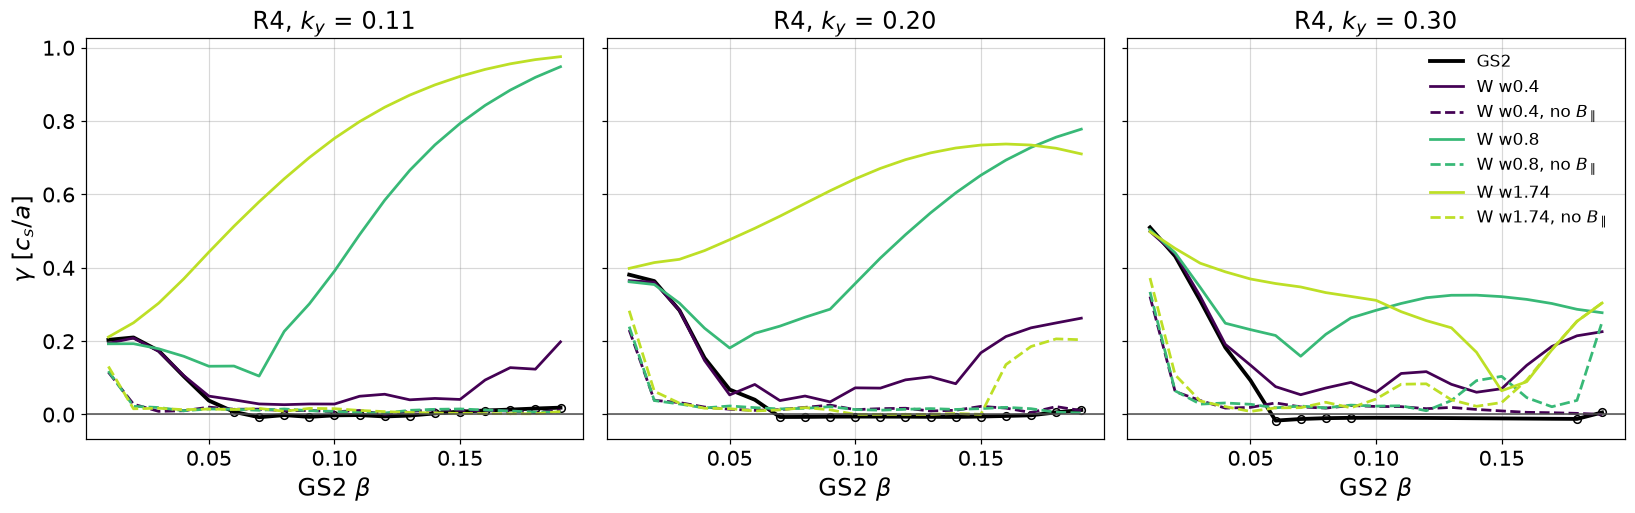

ky 0.112 beta 0.02 (GS2 +0.210) with -> without Bpar: GFTM w0.4 0.208->0.028  GFTM w0.8 0.193->0.022  GFTM w1.74 0.250->0.015
ky 0.112 beta 0.15 (GS2 +0.007) with -> without Bpar: GFTM w0.4 0.041->0.011  GFTM w0.8 0.793->0.015  GFTM w1.74 0.921->0.003
ky 0.200 beta 0.02 (GS2 +0.363) with -> without Bpar: GFTM w0.4 0.360->0.038  GFTM w0.8 0.354->0.038  GFTM w1.74 0.414->0.063
ky 0.200 beta 0.15 (GS2 -0.006) with -> without Bpar: GFTM w0.4 0.168->0.022  GFTM w0.8 0.652->0.016  GFTM w1.74 0.734->0.000
ky 0.300 beta 0.02 (GS2 +0.431) with -> without Bpar: GFTM w0.4 0.438->0.062  GFTM w0.8 0.440->0.064  GFTM w1.74 0.452->0.108
ky 0.300 beta 0.15 (GS2 -0.011) with -> without Bpar: GFTM w0.4 0.070->0.009  GFTM w0.8 0.321->0.104  GFTM w1.74 0.064->0.032


In [22]:
fig_nb, axes = plt.subplots(1, len(iky), figsize=(5 * len(iky), 4.8), sharey=True)
for col, i in enumerate(iky):
    ax = axes[col]
    ax.plot(beta_r4, g["GS2"][i], color="k", lw=2.5, label="GS2", marker="none")
    ax.plot(beta_r4[unconv[i]], g["GS2"][i, unconv[i]], color="k", ls="", marker="o", ms=5, mfc="none")
    for lab, leaf in (("GFTM w0.4", "nobpar_w0p4"), ("GFTM w0.8", "nobpar_w0p8"), ("GFTM w1.74", "nobpar_w1p74")):
        ax.plot(beta_r4, g[lab][i], color=colour[lab], label=lab.replace("GFTM ", "W "), marker="none")
        ax.plot(beta_r4, gc[leaf][col], color=colour[lab], ls="--", label=lab.replace("GFTM ", "W ") + r", no $B_\parallel$", marker="none")
    ax.axhline(0, color="0.3", lw=1, marker="")
    ax.set_title(rf"R4, $k_y$ = {float(gs2[r4].ky[i]):.2f}", fontsize=16)
    ax.set_xlabel(r"GS2 $\beta$", fontsize=16)
    ax.tick_params(labelsize=14)
axes[0].set_ylabel(r"$\gamma$ [$c_s/a$]", fontsize=16)
axes[-1].legend(fontsize=11)
fig_nb.tight_layout()
plt.show()
nobpar = {"GFTM w0.4": "nobpar_w0p4", "GFTM w0.8": "nobpar_w0p8", "GFTM w1.74": "nobpar_w1p74"}
for col, i in enumerate(iky):
    for j in (jlo, jhi):
        print(f"ky {float(gs2[r4].ky[i]):.3f} beta {beta_r4[j]:.2f} (GS2 {g['GS2'][i, j]:+.3f}) with -> without Bpar: " +
              "  ".join(f"{lab} {g[lab][i, j]:.3f}->{gc[leaf][col, j]:.3f}" for lab, leaf in nobpar.items()))

### (8) Is GFTM's large B∥/φ a normalisation convention? Ratio to GS2 vs ky at the β 0.02 control
GFTM's B∥ eigenfunction is its internal field σ, solved with `betasig = 0.5·betae/ky²` (GFTM `gftm_eigensolver.f90`),
and pyro's GFTM reader applies units only, no ky factor. If σ is δB∥ times a power of ky, the GFTM/GS2 ratio of
peak|B∥|/peak|φ| should follow that power of ky where the two codes find the same mode. All 42 ky at β 0.02, cells with
GS2 converged (tol < 1e-2) and γ > 0 in both. A∥ for comparison. Slope from a straight-line fit in log-log.

bpar GFTM w0.4: n 40, ratio GFTM/GS2 at ky 0.11/0.2/0.3 19.95/11.13/7.27, log-log slope -1.25


/scratch_local/ipykernel_1995052/991190010.py:3: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(np.abs(v(e.sel(field=k))), axis=-1) / np.nanmax(np.abs(v(e.sel(field="phi"))), axis=-1)


bpar GFTM w0.8: n 40, ratio GFTM/GS2 at ky 0.11/0.2/0.3 16.96/9.29/6.00, log-log slope -1.24
bpar GFTM w1.74: n 40, ratio GFTM/GS2 at ky 0.11/0.2/0.3 10.10/5.75/3.88, log-log slope -1.40
apar GFTM w0.4: n 40, ratio GFTM/GS2 at ky 0.11/0.2/0.3 0.80/0.81/0.81, log-log slope -1.01
apar GFTM w0.8: n 40, ratio GFTM/GS2 at ky 0.11/0.2/0.3 0.60/0.62/0.61, log-log slope -1.06
apar GFTM w1.74: n 40, ratio GFTM/GS2 at ky 0.11/0.2/0.3 0.32/0.32/0.32, log-log slope -1.29


/scratch_local/ipykernel_1995052/991190010.py:26: UserWarning: The figure layout has changed to tight
  fig_bn.tight_layout()


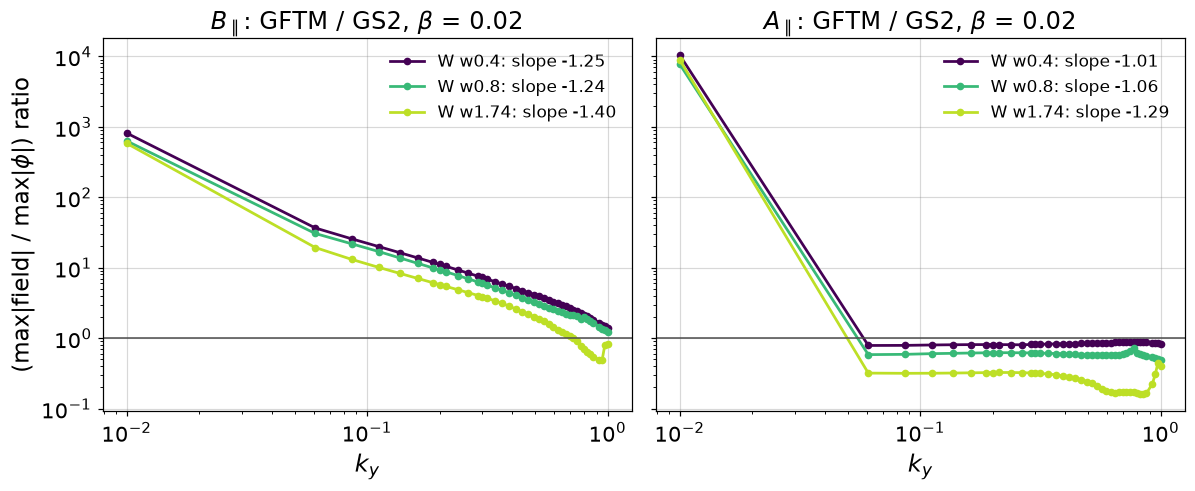

saved 4 figures


In [23]:
def peak_ratio(d, k):
    e = dominant(d, "eigenfunctions")
    return np.nanmax(np.abs(v(e.sel(field=k))), axis=-1) / np.nanmax(np.abs(v(e.sel(field="phi"))), axis=-1)


ky_all = v(R["GS2"].ky)
ok_gs2 = (tol[:, jlo] < 1e-2) & (g["GS2"][:, jlo] > 0)
fig_bn, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, k in zip(axes, ("bpar", "apar")):
    r2 = peak_ratio(R["GS2"], k)[:, jlo]
    for lab in r4_eig:
        ok = ok_gs2 & (g[lab][:, jlo] > 0)
        y = peak_ratio(R[lab], k)[:, jlo] / r2
        slope = np.polyfit(np.log(ky_all[ok]), np.log(y[ok]), 1)[0]
        ax.plot(ky_all[ok], y[ok], color=colour[lab], marker="o", ms=4, label=f"{lab.replace('GFTM ', 'W ')}: slope {slope:.2f}")
        print(f"{k} {lab}: n {ok.sum()}, ratio GFTM/GS2 at ky 0.11/0.2/0.3 "
              f"{'/'.join(f'{y[i]:.2f}' for i in iky)}, log-log slope {slope:.2f}")
    ax.axhline(1, color="0.3", lw=1, marker="")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$k_y$", fontsize=16)
    ax.set_title(rf"{field_label[k]}: GFTM / GS2, $\beta$ = {beta_r4[jlo]:.2f}", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=11)
axes[0].set_ylabel(r"(max|field| / max|$\phi$|) ratio", fontsize=15)
fig_bn.tight_layout()
plt.show()
conv_figs = {"R4_width_scan_vs_beta": fig_ws, "R4_resolution_convergence": fig_res, "R4_nobpar_vs_beta": fig_nb,
             "R4_bpar_apar_ratio_vs_ky": fig_bn}
for name, fig in conv_figs.items():
    fig.savefig(output_dir / f"{name}.png", dpi=150, bbox_inches="tight")
print("saved", len(conv_figs), "figures")

### (9) STEP-EC-HD (S1_3): γ and ω vs q and vs ŝ, GFTM (FILTER=0.5) and TGLF against GS2 (Fusion_PhD-38e9.14)

Same settings as the β scans above, on GS2's exact ky × q and ky × ŝ grids (11 ky, 10 values). Each leaf's `pyroscan.nc` is loaded
with `PyroScanGKOutput.from_netcdf`. Leaves: GFTM `scan_{q,shat}_f05/S1_3/w0p{4,6,7,8}`, TGLF `scan_{q,shat}_modes/S1_3/{default,v5}`, GS2 `scan_{q,shat}/S1_3/parameter_scan_GS2`.
GS2 markers: `mode_classification.indicators(scan, ds)` (scan classifier of GA master, via `sample_pyro`); GFTM/TGLF markers use T and ω only.
This section needs GA master's `mode_classification` (gridded-scan `indicators`); it replaces the per-run `indicators(pyro)` the β cells above call.

In [ ]:
from pyrokinetics.pyroscan import PyroScan, PyroScanGKOutput

s13_case = "S1_3"                                    # STEP-EC-HD
s13_ky_targets = [0.1, 0.2, 0.3, 0.5]                # snapped to the nearest GS2 grid value, shown in the panel titles
s13_xlabel = {"q": r"$q$", "shat": r"$\hat{s}$"}
# label -> (code, project suffix: scan_<par>_<suffix>, leaf). Same settings as the beta scans above.
s13_codes = {
    "GFTM w0.4": ("GFTM", "f05", "w0p4"), "GFTM w0.6": ("GFTM", "f05", "w0p6"),
    "GFTM w0.7": ("GFTM", "f05", "w0p7"), "GFTM w0.8": ("GFTM", "f05", "w0p8"),
    "TGLF default": ("TGLF", "modes", "default"), "TGLF V5": ("TGLF", "modes", "v5"),
}
s13_marker = {"MTM": "^", "KBM": "s", "mixed": "o"}
s13_key = [Line2D([], [], color="k", label="GS2"),
           Line2D([], [], color="C0", ls="-", label="code, dominant mode"),
           Line2D([], [], color="C0", ls="--", label="code, other mode"),
           *[Line2D([], [], color="grey", ls="", marker=m, label=t) for t, m in s13_marker.items()]]


def s13_v(da):
    return np.asarray(getattr(da.data, "magnitude", da.data))


def s13_load(par):
    "GS2 and every code leaf of the S1_3 scan over `par`, from each leaf's pyroscan.nc. Needs the scan classifier of GA master (mc.indicators(scan, ds))."
    leaf = data_root / "GS2" / run_template / f"scan_{par}" / s13_case / "parameter_scan_GS2"
    scan = mc.attach_legacy_funcs(PyroScan(pyro=Pyro(gk_file=leaf / "pyroscan_base.input", gk_code="GS2"), pyroscan_json=leaf / "pyroscan.json",
                                           base_directory=leaf.parent, file_name="gs2.in"))
    ds = PyroScanGKOutput.from_netcdf(leaf / "pyroscan.nc").data
    d = dict(x=s13_v(ds[par]), ky=s13_v(ds.ky), g=s13_v(ds.growth_rate), w=s13_v(ds.mode_frequency), model={})
    d["typ"] = mc.classify(mc.indicators(scan, mc.as_samples(scan, ds))).reshape(d["g"].shape)   # sample order: ky outermost
    for lab, (code, suffix, name) in s13_codes.items():
        c = PyroScanGKOutput.from_netcdf(data_root / code / run_template / f"scan_{par}_{suffix}" / s13_case / name / "pyroscan.nc").data
        assert np.allclose(s13_v(c.ky), d["ky"]) and np.allclose(s13_v(c[par]), d["x"]), (lab, "grid differs from GS2")
        g, w, T = (s13_v(c[k]) for k in ("growth_rate", "mode_frequency", "tearing_parameter"))
        d["model"][lab] = dict(g=g, w=w, typ=mc.classify_T_omega({"T": T, "omega": mc.ION_DIRECTION * w}),
                               dom=np.nan_to_num(g, nan=-np.inf).argmax(-1))     # dominant = argmax gamma over mode
    return d


def s13_plot(par, d):
    "Rows: gamma, omega. Columns: ky. One figure per code leaf; a marker only where that mode has gamma > gamma_floor."
    iky = [int(np.abs(d["ky"] - k).argmin()) for k in s13_ky_targets]
    x, figs = d["x"], {}
    for lab, m in d["model"].items():
        fig, axes = plt.subplots(2, len(iky), figsize=(4 * len(iky), 6.4), sharex=True)
        for col, (i, target) in enumerate(zip(iky, s13_ky_targets)):
            dom = m["dom"][i]
            for row, q in enumerate(("g", "w")):
                ax = axes[row, col]
                ax.plot(x, d[q][i], color="k")
                for j, t in enumerate(d["typ"][i]):
                    if d["g"][i, j] > gamma_floor:
                        ax.plot(x[j], d[q][i, j], color="k", marker=s13_marker[t], ls="")
                for k, (ls, is_dom) in enumerate((("-", dom), ("--", 1 - dom))):    # dominant solid, the other of 2 modes dashed
                    y = np.take_along_axis(m[q][i], is_dom[:, None], 1)[:, 0]
                    gk = np.take_along_axis(m["g"][i], is_dom[:, None], 1)[:, 0]
                    tk = np.take_along_axis(m["typ"][i], is_dom[:, None], 1)[:, 0]
                    ax.plot(x, y, color="C0", ls=ls)
                    for j in np.flatnonzero(gk > gamma_floor):
                        ax.plot(x[j], y[j], color="C0", marker=s13_marker[tk[j]], ls="", mfc="C0" if k == 0 else "none")
            axes[0, col].set_title(f"ky = {d['ky'][i]:.3f} (target {target})")
            axes[1, col].set_xlabel(s13_xlabel[par])
        axes[0, 0].set_ylabel(r"$\gamma$ [$c_s/a$]")
        axes[1, 0].set_ylabel(r"$\omega$ [$c_s/a$] (ion direction > 0)")
        axes[0, -1].legend(handles=s13_key, loc="best", fontsize=8)
        fig.suptitle(f"{s13_case} {par} scan: {lab} vs GS2. Dominant = solid line, filled marker; other mode dashed, open marker", y=1.02)
        figs[lab] = fig
        plt.close(fig)
    return figs


def s13_save(par, figs):
    output_dir = ROOT / "Plots" / analysis_name
    output_dir.mkdir(parents=True, exist_ok=True)
    for lab, fig in figs.items():
        fig.savefig(output_dir / f"{s13_case}_{par}_{lab.replace(' ', '_').replace('.', 'p')}.png", dpi=150, bbox_inches="tight")
    print("saved", len(figs), "figures to", output_dir)


#### q scan (ŝ and everything else at the base values)

In [1]:
d_q = s13_load("q")
figs_q = s13_plot("q", d_q)
s13_save("q", figs_q)
print("GS2 types at gamma > 0:", {t: int(((d_q["typ"] == t) & (d_q["g"] > gamma_floor)).sum()) for t in s13_marker})

#### ŝ scan (q and everything else at the base values)

In [1]:
d_shat = s13_load("shat")
figs_shat = s13_plot("shat", d_shat)
s13_save("shat", figs_shat)
print("GS2 types at gamma > 0:", {t: int(((d_shat["typ"] == t) & (d_shat["g"] > gamma_floor)).sum()) for t in s13_marker})